# Fraud Anomaly Detection Pipeline — Code-First Walkthrough

**Unsupervised anomaly detection on `data/bank_transactions_data_2.csv`** (2,512 retail-banking
transactions, 495 accounts, no fraud label). This notebook is the raw, run-it-yourself companion
to the 17-phase research writeup in `research/01_business_understanding.md` through
`research/15_final_research_report.md`. Every table and plot below is produced by the code cell
directly above it — nothing here is typed in from memory of the reports.

**Measured runtime of this notebook, executed top-to-bottom from a clean kernel: see the final
cell.** As built and tested, a full run (all 16 sections) completes in under 3 minutes on a
standard CPU-only machine (no GPU required — every model here is either classical scikit-learn or
a small PyTorch network with a few thousand parameters).

**How "live" vs. "loaded" is handled, stated once here rather than re-litigated every section.**
This project already trained 12 anomaly-detection models, ran a 5-bootstrap stability study, a
60-trial-plus hyperparameter search, and full-dataset SHAP explanations — some of that is
minutes-to-tens-of-minutes of compute that would make this notebook slow and repetitive to re-run
in full every time. The convention used throughout:

- Sections that are cheap (data loading, feature engineering, scaling, a single model fit, SHAP on
  a small sample, all plotting, all aggregation math) are run **live, in full**, in this notebook.
- Sections that were expensive to build the first time (the full 12-model bootstrap-stability
  study, the full Optuna search, full-dataset SHAP on the autoencoder) are run **live in a clearly
  labeled, reduced form** (fewer trials / fewer bootstrap runs / a row sample) **and** the
  already-computed full-scale result is loaded from `artifacts_research/` and shown alongside it,
  so the reduced live run is never mistaken for the final, reported research number.
- Every cell that loads a precomputed artifact says so explicitly in the markdown directly above
  it.

**Structure** (mirrors `research/01` through `research/15`):
1. Business Understanding 2. Data Understanding 3. Data Quality 4. EDA 5. Feature Engineering
6. Preprocessing & Dimensionality Reduction 7. Model Development (12-model comparison)
8. Hyperparameter Optimization 9. Evaluation Framework 10. Explainability (SHAP)
11. Ensemble Scoring 12. Threshold Optimization 13. Final Model Selection
14. Deployment Architecture 15. Monitoring Framework 16. Conclusion

In [1]:
import time
NOTEBOOK_START_TIME = time.time()

### Environment setup

Locates the project root from this notebook's own location (`../` from `notebooks/`), so every
path below is relative — no hardcoded Windows paths. If this notebook is opened in Google Colab
with only the `.ipynb` uploaded (no sibling `data/`, `src_research/`, `artifacts_research/`
folders), it falls back to a file-upload widget so the pipeline can still run against the raw CSV.

In [2]:
import os
import sys

def _in_colab():
    try:
        return 'google.colab' in str(get_ipython())
    except NameError:
        return False

IN_COLAB = _in_colab()
NOTEBOOK_DIR = os.getcwd()


def _find_root():
    candidates = [
        os.path.abspath(os.path.join(NOTEBOOK_DIR, "..")),
        NOTEBOOK_DIR,
        os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "..")),
    ]
    for c in candidates:
        if os.path.exists(os.path.join(c, "data", "bank_transactions_data_2.csv")):
            return c
    return None

ROOT = _find_root()

if ROOT is None and IN_COLAB:
    print("Running in Colab and the project folder structure was not found next to this notebook.")
    print("Upload the project as a .zip (the whole placement-round-fraud-kit folder) to continue,")
    print("or upload just data/bank_transactions_data_2.csv for a data-only run.")
    from google.colab import files
    uploaded = files.upload()
    import zipfile
    for fname in uploaded:
        if fname.endswith(".zip"):
            with zipfile.ZipFile(fname) as z:
                z.extractall(".")
    ROOT = _find_root() or os.getcwd()
elif ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/bank_transactions_data_2.csv relative to this notebook. "
        "Run this notebook from its original location inside placement-round-fraud-kit/notebooks/."
    )

DATA_DIR = os.path.join(ROOT, "data")
RAW_CSV = os.path.join(DATA_DIR, "bank_transactions_data_2.csv")
ARTIFACTS_DIR = os.path.join(ROOT, "artifacts_research")
MODELS_DIR = os.path.join(ARTIFACTS_DIR, "models")
SRC_RESEARCH_DIR = os.path.join(ROOT, "src_research")
HAS_SRC_RESEARCH = os.path.isdir(SRC_RESEARCH_DIR)

if HAS_SRC_RESEARCH and SRC_RESEARCH_DIR not in sys.path:
    sys.path.insert(0, SRC_RESEARCH_DIR)

print(f"IN_COLAB={IN_COLAB}  ROOT={ROOT}")
print(f"Data file found: {os.path.exists(RAW_CSV)}")
print(f"Artifacts folder found: {os.path.isdir(ARTIFACTS_DIR)}")
print(f"src_research importable: {HAS_SRC_RESEARCH}")

IN_COLAB=False  ROOT=C:\Users\Lenovo\Downloads\BAF-Fraud-Detection-Kit\placement-round-fraud-kit
Data file found: True
Artifacts folder found: True
src_research importable: True


In [3]:
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print("Setup complete.")

Setup complete.


## 1. Business Understanding

*Mirrors `research/01_business_understanding.md`.*

The task: detect fraudulent transactions in a retail-banking ledger that carries **no fraud
label**. That single constraint drives every later decision — there is nothing to train a
classifier against, no precision/recall to compute, and no cost-optimal threshold to solve for in
the supervised sense. The reframed problem is: identify transactions that deviate from established
per-account behavior, rank them by how strongly they deviate, and give a human investigator enough
context to judge them, while being explicit about the difference between "statistically unusual"
and "confirmed fraudulent."

Six fraud typologies were mapped against what this schema can actually observe *before* any
modeling began (a design table, reproduced here for reference — not a number computed by this
notebook):

In [4]:
scenario_table = pd.DataFrame([
    {"Scenario": "Account takeover", "Observable here?": "Yes -- strongest fit",
     "Proxy features": "DeviceNoveltyFlag, LocationNoveltyFlag, LoginAttempts, Amount_vs_AccountAvg"},
    {"Scenario": "Transaction bursts / card testing", "Observable here?": "Yes",
     "Proxy features": "Per-account velocity features, TimeSinceLastTxn"},
    {"Scenario": "Unusual spending / compromised card", "Observable here?": "Yes",
     "Proxy features": "Rolling deviation features, Amount_vs_AccountAvg"},
    {"Scenario": "Mule accounts", "Observable here?": "Partially -- shared infra visible, fund-flow not",
     "Proxy features": "DeviceTxnCount, IPTxnCount, MerchantTxnCount"},
    {"Scenario": "Synthetic identities", "Observable here?": "Weakly -- no KYC/account-opening field",
     "Proxy features": "CustomerOccupation / CustomerAge vs. behaviour"},
    {"Scenario": "Money laundering (layering)", "Observable here?": "No direct signal -- needs a counterparty ledger",
     "Proxy features": "none"},
])
scenario_table

,Scenario,Observable here?,Proxy features
0,Account takeover,Yes -- strongest fit,"DeviceNoveltyFlag, LocationNoveltyFlag, LoginA..."
1,Transaction bursts / card testing,Yes,"Per-account velocity features, TimeSinceLastTxn"
2,Unusual spending / compromised card,Yes,"Rolling deviation features, Amount_vs_AccountAvg"
3,Mule accounts,"Partially -- shared infra visible, fund-flow not","DeviceTxnCount, IPTxnCount, MerchantTxnCount"
4,Synthetic identities,Weakly -- no KYC/account-opening field,CustomerOccupation / CustomerAge vs. behaviour
5,Money laundering (layering),No direct signal -- needs a counterparty ledger,none


Layering (money laundering) is explicitly out of scope and is never claimed as detected anywhere
downstream, even if an anomaly model happens to flag a transaction a human might narrate that way.
The operating definition of "normal" used throughout is **per-account, not global** — a $14 debit
is unremarkable for one customer and a red flag for another.

## 2. Data Understanding

*Mirrors `research/02_data_understanding.md`. Everything below is computed live from the raw CSV
loaded just now — no numbers are typed in from the report.*

In [5]:
raw = pd.read_csv(RAW_CSV)
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(5)

Shape: 2,512 rows x 16 columns


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,11-04-2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,04-11-2024 08:08
1,TX000002,AC00455,376.24,27-06-2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,04-11-2024 08:09
2,TX000003,AC00019,126.29,10-07-2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,04-11-2024 08:07
3,TX000004,AC00070,184.50,05-05-2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,04-11-2024 08:09
4,TX000005,AC00411,13.45,16-10-2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,04-11-2024 08:06


In [6]:
raw.dtypes.to_frame("dtype")

,dtype
TransactionID,str
AccountID,str
TransactionAmount,float64
TransactionDate,str
TransactionType,str
Location,str
DeviceID,str
IP Address,str
MerchantID,str
Channel,str


In [7]:
profile = pd.DataFrame({
    "n_unique": raw.nunique(),
    "n_missing": raw.isna().sum(),
    "pct_missing": (raw.isna().mean() * 100).round(3),
})
profile

,n_unique,n_missing,pct_missing
TransactionID,2512,0,0.0
AccountID,495,0,0.0
TransactionAmount,2455,0,0.0
TransactionDate,2405,0,0.0
TransactionType,2,0,0.0
Location,43,0,0.0
DeviceID,681,0,0.0
IP Address,592,0,0.0
MerchantID,100,0,0.0
Channel,3,0,0.0


In [8]:
n_duplicate_rows = int(raw.duplicated().sum())
n_duplicate_txn_ids = int(raw["TransactionID"].duplicated().sum())
print(f"Duplicate rows: {n_duplicate_rows}")
print(f"Duplicate TransactionIDs: {n_duplicate_txn_ids}")

acct_counts = raw.groupby("AccountID").size()
print(f"\nUnique accounts: {raw['AccountID'].nunique()}")
print(f"Transactions per account -- mean: {acct_counts.mean():.2f}, "
      f"median: {acct_counts.median():.0f}, min: {acct_counts.min()}, max: {acct_counts.max()}")
print(f"Accounts with exactly 1 transaction (no history to build a baseline against): "
      f"{(acct_counts == 1).sum()}")

Duplicate rows: 0
Duplicate TransactionIDs: 0

Unique accounts: 495
Transactions per account -- mean: 5.07, median: 5, min: 1, max: 12
Accounts with exactly 1 transaction (no history to build a baseline against): 24


In [9]:
txn_dt = pd.to_datetime(raw["TransactionDate"], format="%d-%m-%Y %H:%M")
span_days = (txn_dt.max() - txn_dt.min()).days
print(f"TransactionDate span: {txn_dt.min()} to {txn_dt.max()}  ({span_days} days)")
print(f"Transactions/day (this sample): {len(raw) / span_days:.2f}")

TransactionDate span: 2023-01-02 16:00:00 to 2024-01-01 18:21:00  (364 days)
Transactions/day (this sample): 6.90


## 3. Data Quality

*Mirrors `research/03_data_quality_and_eda.md` §1. Two structural defects in the raw data are
checked directly below, not assumed from the report.*

In [10]:
prev_dt = pd.to_datetime(raw["PreviousTransactionDate"], format="%d-%m-%Y %H:%M")
n_distinct_prev = prev_dt.nunique()
prev_span_minutes = (prev_dt.max() - prev_dt.min()).total_seconds() / 60.0
print(f"PreviousTransactionDate -- distinct timestamps across all {len(raw)} rows: {n_distinct_prev}")
print(f"PreviousTransactionDate -- span of those distinct timestamps: {prev_span_minutes:.1f} minutes, "
      f"on {prev_dt.min().date()}")
print(f"Latest TransactionDate in the data: {txn_dt.max().date()}")
print("Verdict: PreviousTransactionDate is a single bulk-export moment stamped on every row, "
      "not per-account history -- confirmed directly, not assumed. Every recency/velocity feature "
      "downstream is derived from TransactionDate sorted per account instead.")

PreviousTransactionDate -- distinct timestamps across all 2512 rows: 7
PreviousTransactionDate -- span of those distinct timestamps: 6.0 minutes, on 2024-11-04
Latest TransactionDate in the data: 2024-01-01
Verdict: PreviousTransactionDate is a single bulk-export moment stamped on every row, not per-account history -- confirmed directly, not assumed. Every recency/velocity feature downstream is derived from TransactionDate sorted per account instead.


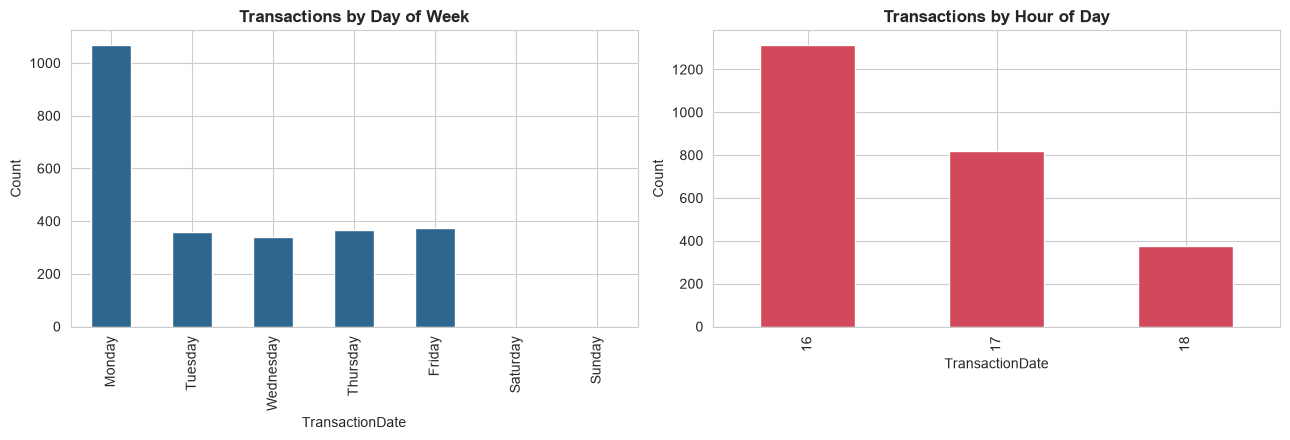

Weekend transactions: 0.00% of all rows
Hour range covered: [16, 17, 18]


In [11]:
weekday_counts = txn_dt.dt.day_name().value_counts()
hour_counts = txn_dt.dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts.reindex(weekday_order).fillna(0).plot(kind="bar", ax=axes[0], color="#2F6690")
axes[0].set_title("Transactions by Day of Week")
axes[0].set_ylabel("Count")
hour_counts.plot(kind="bar", ax=axes[1], color="#D1495B")
axes[1].set_title("Transactions by Hour of Day")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

weekend_pct = 100 * txn_dt.dt.dayofweek.isin([5, 6]).mean()
print(f"Weekend transactions: {weekend_pct:.2f}% of all rows")
print(f"Hour range covered: {sorted(hour_counts.index.tolist())}")

Confirmed directly: **zero weekend transactions**, and every transaction falls inside a narrow
late-afternoon window. This is a data-generation artifact, not a real-world pattern, and it caps
what time-of-day features can contribute downstream (there is no overnight/weekend baseline for a
"3am transaction" signal to stand out against).

## 4. Exploratory Data Analysis

*Mirrors `research/03_data_quality_and_eda.md` §2-4. Distributions, correlations, and one
categorical association test, all computed live below.*

In [12]:
numeric_cols = ["TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance"]
desc_stats = raw[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T
desc_stats["skew"] = raw[numeric_cols].skew()
desc_stats["kurtosis"] = raw[numeric_cols].kurtosis()
desc_stats.round(3)

,mean,median,std,min,max,skew,kurtosis
TransactionAmount,297.594,211.14,291.946,0.26,1919.11,1.740,3.643
CustomerAge,44.674,45.00,17.792,18.00,80.00,0.148,-1.224
TransactionDuration,119.643,112.50,69.964,10.00,300.00,0.599,-0.259
LoginAttempts,1.125,1.00,0.603,1.00,5.00,5.173,26.669
AccountBalance,5114.303,4735.51,3900.942,101.25,14977.99,0.601,-0.565


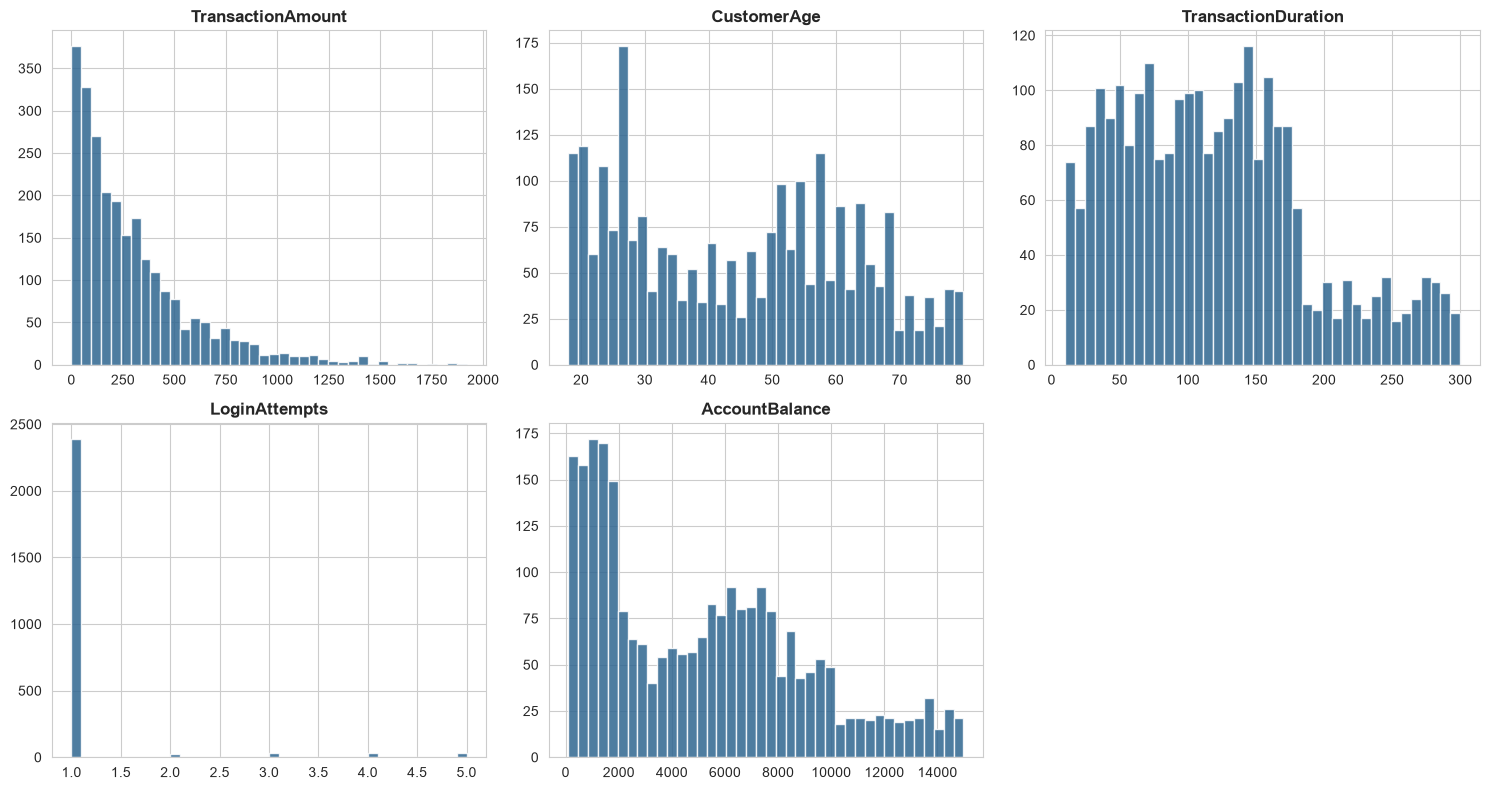

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(raw[col], bins=40, color="#2F6690", alpha=0.85)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

LoginAttempts value counts:
LoginAttempts
1    2390
2      27
3      31
4      32
5      32
Name: count, dtype: int64

Rows with exactly 1 login attempt: 95.14%  (skew=5.17, kurtosis=26.67)


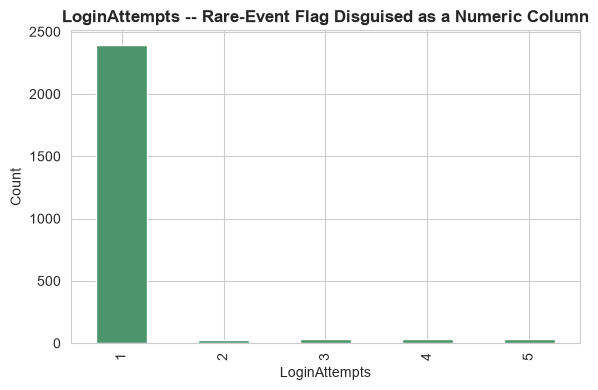

In [14]:
login_vc = raw["LoginAttempts"].value_counts().sort_index()
pct_at_1 = 100 * (raw["LoginAttempts"] == 1).mean()
print(f"LoginAttempts value counts:\n{login_vc}\n")
print(f"Rows with exactly 1 login attempt: {pct_at_1:.2f}%  "
      f"(skew={raw['LoginAttempts'].skew():.2f}, kurtosis={raw['LoginAttempts'].kurtosis():.2f})")

fig, ax = plt.subplots(figsize=(6, 4))
login_vc.plot(kind="bar", ax=ax, color="#4C956C")
ax.set_title("LoginAttempts -- Rare-Event Flag Disguised as a Numeric Column")
ax.set_xlabel("LoginAttempts"); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

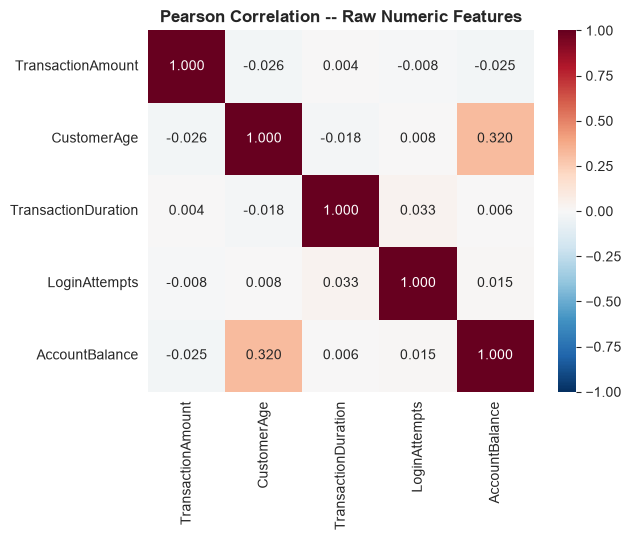

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
TransactionAmount,1.000,-0.026,0.004,-0.008,-0.025
CustomerAge,-0.026,1.000,-0.018,0.008,0.320
TransactionDuration,0.004,-0.018,1.000,0.033,0.006
LoginAttempts,-0.008,0.008,0.033,1.000,0.015
AccountBalance,-0.025,0.320,0.006,0.015,1.000


In [15]:
corr_pearson = raw[numeric_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr_pearson, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pearson Correlation -- Raw Numeric Features")
plt.tight_layout()
plt.show()
corr_pearson.round(3)

In [16]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(raw["Channel"], raw["TransactionType"])
chi2, p_value, dof, expected = chi2_contingency(ct)
print(f"Chi-square test, Channel x TransactionType: chi2={chi2:.2f}, dof={dof}, p={p_value:.3e}")
ct_pct = pd.crosstab(raw["Channel"], raw["TransactionType"], normalize="index") * 100
ct_pct.round(1)

Chi-square test, Channel x TransactionType: chi2=136.91, dof=2, p=1.868e-30


TransactionType,Credit,Debit
Channel,,
ATM,8.8,91.2
Branch,28.9,71.1
Online,30.1,69.9


In [17]:
atm_credit = raw[(raw["Channel"] == "ATM") & (raw["TransactionType"] == "Credit")]
print(f"ATM + Credit combination: {len(atm_credit)} rows ({100*len(atm_credit)/len(raw):.2f}% of data) "
      "-- rare and statistically distinctive enough to become a dedicated interaction feature "
      "in Phase 5 (ATM_Credit_InteractionFlag).")

ATM + Credit combination: 73 rows (2.91% of data) -- rare and statistically distinctive enough to become a dedicated interaction feature in Phase 5 (ATM_Credit_InteractionFlag).


In [18]:
# Quick, honest outlier-method comparison on TransactionAmount (IQR vs. Modified Z-score),
# computed live; a five-method comparison across all numeric features already exists as a
# research artifact and is loaded alongside for the full picture.
amt = raw["TransactionAmount"]
q1, q3 = amt.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_flag = (amt < q1 - 1.5 * iqr) | (amt > q3 + 1.5 * iqr)

med = amt.median()
mad = (amt - med).abs().median()
mod_z = 0.6745 * (amt - med) / mad
modz_flag = mod_z.abs() > 3.5

print(f"IQR method flags {iqr_flag.sum()} rows ({100*iqr_flag.mean():.2f}%) on TransactionAmount")
print(f"Modified Z-score flags {modz_flag.sum()} rows ({100*modz_flag.mean():.2f}%) on TransactionAmount")
print(f"Jaccard overlap between the two methods: "
      f"{(iqr_flag & modz_flag).sum() / (iqr_flag | modz_flag).sum():.3f}")

outlier_comparison_path = os.path.join(ARTIFACTS_DIR, "outlier_comparison.csv")
if os.path.exists(outlier_comparison_path):
    print("\nLoaded (Phase 3 research artifact) -- full 5-method x 5-feature outlier comparison:")
    display(pd.read_csv(outlier_comparison_path))

IQR method flags 113 rows (4.50%) on TransactionAmount
Modified Z-score flags 100 rows (3.98%) on TransactionAmount
Jaccard overlap between the two methods: 0.885

Loaded (Phase 3 research artifact) -- full 5-method x 5-feature outlier comparison:


,feature,IQR_count,ZScore_count,ModifiedZScore_count,Percentile_1_99_count,IsolationForest_joint_count
0,TransactionAmount,113,48,100,52,126
1,CustomerAge,0,0,0,17,126
2,TransactionDuration,0,0,0,52,126
3,LoginAttempts,122,95,122,0,126
4,AccountBalance,0,0,0,52,126


## 5. Feature Engineering

*Mirrors `research/04_feature_engineering.md`. The feature functions below are imported directly
from `src_research/04_feature_engineering.py` and run live on the raw data* (not re-typed) *-- this
is the actual Phase 5 pipeline code executing in this notebook, producing the 46-feature matrix
fresh, then cross-checked row-for-row against the already-saved
`artifacts_research/features_v2.csv` to confirm this notebook reproduces the research result
exactly.*

In [19]:
if HAS_SRC_RESEARCH:
    import importlib
    fe_mod = importlib.import_module("04_feature_engineering")

    t0 = time.time()
    df_sorted = fe_mod._sorted_raw()
    v1d, v7d = fe_mod.velocity_features(df_sorted)
    roll_exp = fe_mod.rolling_and_expanding_features(df_sorted)
    ratio_dev = fe_mod.ratio_and_deviation_features(df_sorted, roll_exp)
    cyc = fe_mod.cyclical_time_features(df_sorted)
    behav = fe_mod.behavioral_features(df_sorted, roll_exp)
    net = fe_mod.network_proxy_features(df_sorted)
    loc_freq = fe_mod.frequency_encoding(df_sorted, "Location", "Location_Freq")
    new_features_live = pd.concat([v1d, v7d, roll_exp, ratio_dev, cyc, behav, net, loc_freq], axis=1)
    fe_elapsed = time.time() - t0
    print(f"Live feature engineering (Phase 5 functions, real code): {fe_elapsed:.2f}s "
          f"for {new_features_live.shape[0]} rows x {new_features_live.shape[1]} new columns")
else:
    new_features_live = None
    print("src_research not importable in this environment -- skipping live feature-function run; "
          "features_v2.csv is loaded directly below instead.")

Live feature engineering (Phase 5 functions, real code): 3.22s for 2512 rows x 26 new columns


In [20]:
features_v2 = pd.read_csv(os.path.join(ARTIFACTS_DIR, "features_v2.csv"))
print(f"features_v2.csv: {features_v2.shape[0]:,} rows x {features_v2.shape[1]} columns "
      f"(46 model features + TransactionID + AccountID)")

if new_features_live is not None:
    # Verify this notebook's live run reproduces the saved artifact's new-feature columns exactly.
    shared_cols = [c for c in new_features_live.columns if c in features_v2.columns]
    match = np.allclose(
        new_features_live[shared_cols].values.astype(float),
        features_v2[shared_cols].reset_index(drop=True).values.astype(float),
        atol=1e-6, equal_nan=True,
    )
    print(f"Live-computed features match the saved artifact row-for-row: {'MATCH' if match else 'MISMATCH'}")

features_v2.head(3)

features_v2.csv: 2,512 rows x 48 columns (46 model features + TransactionID + AccountID)
Live-computed features match the saved artifact row-for-row: MATCH


,TransactionID,AccountID,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,Amount_vs_TypeAvg,DeviceTxnCount,IPTxnCount,MerchantTxnCount,Amount_vs_AccountAvg,DeviceNoveltyFlag,LocationNoveltyFlag,TimeSinceLastTxn,Location_enc,TransactionType_Debit,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,Velocity_1D_Count,Velocity_7D_Count,Expanding_MeanAmount,Expanding_MedianAmount,Expanding_StdAmount,Expanding_MinAmount,Expanding_MaxAmount,Rolling3_MeanAmount,Rolling3_StdAmount,Amount_to_Balance_Ratio,Amount_to_RollingMean_Ratio,Amount_minus_ExpandingMean,Amount_minus_ExpandingMedian,Amount_ZScore_Account,Hour_sin,Hour_cos,DOW_sin,DOW_cos,CustomerTxnCountSoFar,SpendCV_Account,ElevatedLoginFlag,ATM_Credit_InteractionFlag,DeviceSharedAccounts_Prior,IPSharedAccounts_Prior,MerchantSharedAccounts_Prior,Location_Freq
0,TX001313,AC00001,47.79,25,37,1,1649.92,-0.837995,8,3,21,-0.837995,1,1,936.216667,10,True,True,False,False,False,True,0.0,0.0,297.593778,211.14,0.0,0.26,1919.11,297.593778,0.0,0.028965,0.160588,-249.803778,-163.35,-17.112998,-0.965926,-0.258819,-0.433884,-0.900969,0,0.0,0,0,5.0,1.0,14.0,0.024682
1,TX002017,AC00001,212.97,59,178,1,4180.40,-0.278046,1,5,26,3.456372,1,1,1439.933333,1,True,False,True,True,False,False,0.0,0.0,47.790000,47.79,0.0,47.79,47.79,47.790000,0.0,0.050945,4.456372,165.180000,165.18,11.315782,-0.961262,-0.275637,0.781831,0.623490,1,0.0,0,0,0.0,1.0,23.0,0.024283
2,TX002121,AC00002,476.99,23,187,1,1154.48,0.616963,4,7,17,0.616963,1,1,936.216667,36,True,False,True,False,False,True,0.0,0.0,297.593778,211.14,0.0,0.26,1919.11,297.593778,0.0,0.413164,1.602822,179.396222,265.85,12.289675,-0.866025,-0.500000,0.781831,0.623490,0,0.0,0,0,0.0,0.0,0.0,0.023487


In [21]:
feature_families = {
    "Velocity": ["Velocity_1D_Count", "Velocity_7D_Count"],
    "Rolling/Expanding amount baselines": ["Expanding_MeanAmount", "Expanding_StdAmount", "Rolling3_MeanAmount"],
    "Ratio / deviation": ["Amount_to_Balance_Ratio", "Amount_ZScore_Account", "Amount_vs_AccountAvg"],
    "Cyclical time": ["Hour_sin", "Hour_cos", "DOW_sin", "DOW_cos"],
    "Behavioral": ["CustomerTxnCountSoFar", "SpendCV_Account", "ElevatedLoginFlag", "ATM_Credit_InteractionFlag"],
    "Network proxy": ["DeviceSharedAccounts_Prior", "IPSharedAccounts_Prior", "MerchantSharedAccounts_Prior"],
}
for family, cols in feature_families.items():
    print(f"\n--- {family} ---")
    display(features_v2[cols].describe().T.round(3))


--- Velocity ---


,count,mean,std,min,25%,50%,75%,max
Velocity_1D_Count,2512.0,0.021,0.148,0.0,0.0,0.0,0.0,2.0
Velocity_7D_Count,2512.0,0.094,0.311,0.0,0.0,0.0,0.0,2.0



--- Rolling/Expanding amount baselines ---


,count,mean,std,min,25%,50%,75%,max
Expanding_MeanAmount,2512.0,295.415,167.509,0.86,191.784,297.594,349.562,1512.990
Expanding_StdAmount,2512.0,145.971,169.173,0.00,0.000,99.968,247.673,1061.113
Rolling3_MeanAmount,2512.0,297.166,178.667,0.86,176.568,297.594,355.997,1512.990



--- Ratio / deviation ---


...

,count,mean,std,min,25%,50%,75%,max
Hour_sin,2512.0,-0.953,0.040,-1.000,-0.990,-0.962,-0.921,-0.866
Hour_cos,2512.0,-0.225,0.200,-0.500,-0.391,-0.271,-0.083,0.255
DOW_sin,2512.0,0.244,0.461,-0.434,0.000,0.000,0.782,0.975
DOW_cos,2512.0,0.219,0.825,-0.901,-0.901,0.623,1.000,1.000



--- Behavioral ---


,count,mean,std,min,25%,50%,75%,max
CustomerTxnCountSoFar,2512.0,2.555,2.173,0.0,1.0,2.000,4.000,11.000
SpendCV_Account,2512.0,0.502,0.470,0.0,0.0,0.541,0.888,1.752
ElevatedLoginFlag,2512.0,0.049,0.215,0.0,0.0,0.000,0.000,1.000
ATM_Credit_InteractionFlag,2512.0,0.029,0.168,0.0,0.0,0.000,0.000,1.000



--- Network proxy ---


,count,mean,std,min,25%,50%,75%,max
DeviceSharedAccounts_Prior,2512.0,1.775,1.656,0.0,0.0,1.0,3.0,8.0
IPSharedAccounts_Prior,2512.0,2.068,1.870,0.0,1.0,2.0,3.0,12.0
MerchantSharedAccounts_Prior,2512.0,12.308,7.857,0.0,6.0,12.0,18.0,43.0


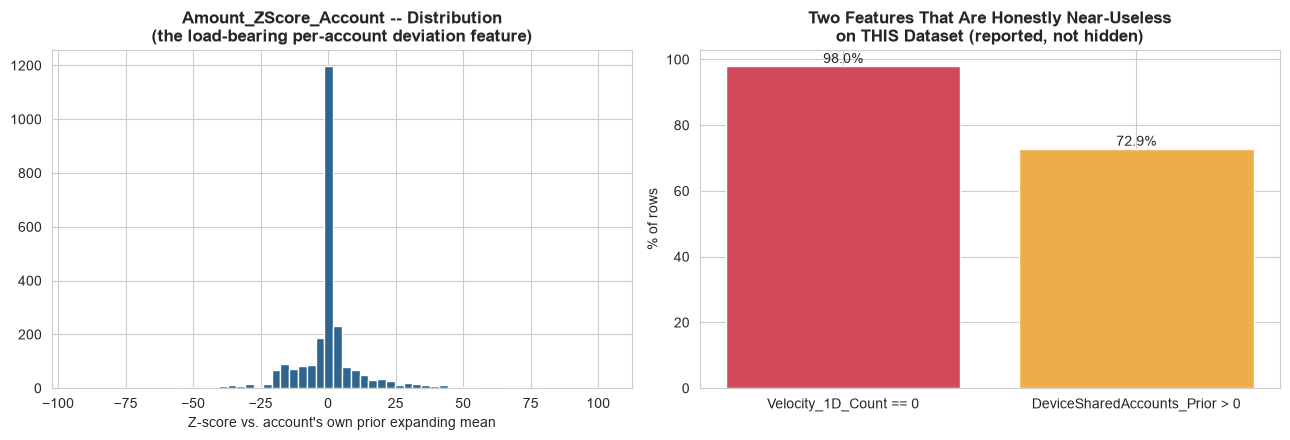

Amount_ZScore_Account range: [-92.60, 102.80]
Velocity_1D_Count is exactly zero for 98.0% of rows -- a rare high-precision flag on this data, not a graded signal (495 accounts averaging 5.08 transactions across 364 days).


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(features_v2["Amount_ZScore_Account"], bins=60, color="#2F6690")
axes[0].set_title("Amount_ZScore_Account -- Distribution\n(the load-bearing per-account deviation feature)")
axes[0].set_xlabel("Z-score vs. account's own prior expanding mean")

velocity_zero_pct = 100 * (features_v2["Velocity_1D_Count"] == 0).mean()
network_share_pct = 100 * (features_v2["DeviceSharedAccounts_Prior"] > 0).mean()
bars = axes[1].bar(
    ["Velocity_1D_Count == 0", "DeviceSharedAccounts_Prior > 0"],
    [velocity_zero_pct, network_share_pct],
    color=["#D1495B", "#EDAE49"],
)
axes[1].set_ylabel("% of rows")
axes[1].set_title("Two Features That Are Honestly Near-Useless\non THIS Dataset (reported, not hidden)")
axes[1].bar_label(bars, fmt="%.1f%%")
plt.tight_layout()
plt.show()

print(f"Amount_ZScore_Account range: [{features_v2['Amount_ZScore_Account'].min():.2f}, "
      f"{features_v2['Amount_ZScore_Account'].max():.2f}]")
print(f"Velocity_1D_Count is exactly zero for {velocity_zero_pct:.1f}% of rows -- a rare "
      "high-precision flag on this data, not a graded signal (495 accounts averaging 5.08 "
      "transactions across 364 days).")

## 6. Preprocessing & Dimensionality Reduction

*Mirrors `research/05_feature_selection_and_preprocessing.md`. The train/val split and
`RobustScaler` are fit live below on the exact same `random_state=42` split used everywhere in
this project, so every downstream section is scored consistently.*

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

with open(os.path.join(ARTIFACTS_DIR, "autoencoder_config.json")) as f:
    ae_config = json.load(f)
FEATURE_COLS = ae_config["feature_cols"]
print(f"Modeling feature set: {len(FEATURE_COLS)} columns (matches the trained autoencoder's schema)")

X = features_v2[FEATURE_COLS].astype(float).values
idx_train, idx_val = train_test_split(np.arange(len(features_v2)), test_size=0.2, random_state=RANDOM_STATE)

scaler_live = RobustScaler().fit(X[idx_train])
X_train = scaler_live.transform(X[idx_train])
X_val = scaler_live.transform(X[idx_val])
X_all = scaler_live.transform(X)
print(f"Train rows: {len(idx_train)}, Val rows: {len(idx_val)}")

# Cross-check against the saved production scaler (loaded, not refit)
saved_scaler = joblib.load(os.path.join(MODELS_DIR, "shared_robust_scaler.pkl"))
scaler_match = np.allclose(scaler_live.center_, saved_scaler.center_) and np.allclose(scaler_live.scale_, saved_scaler.scale_)
print(f"Live-fit scaler matches saved artifacts_research/models/shared_robust_scaler.pkl: "
      f"{'MATCH' if scaler_match else 'MISMATCH'}")

Modeling feature set: 46 columns (matches the trained autoencoder's schema)
Train rows: 2009, Val rows: 503
Live-fit scaler matches saved artifacts_research/models/shared_robust_scaler.pkl: MATCH


In [24]:
# Skewness invariance under scaling -- a genuine, checked-live finding, not assumed.
raw_skew = features_v2["TransactionAmount"].skew()
scaled_amt_idx = FEATURE_COLS.index("TransactionAmount")
scaled_skew = pd.Series(X_all[:, scaled_amt_idx]).skew()
print(f"TransactionAmount skew, raw: {raw_skew:.4f}")
print(f"TransactionAmount skew, RobustScaler-scaled: {scaled_skew:.4f}")
print("Confirms skew is invariant under this affine scaler -- a scaler choice cannot be justified "
      "by comparing skew; Phase 6 instead compared each scaler's sensitivity to trimming the top 1% "
      "of values, and picked RobustScaler for the lowest such sensitivity.")

TransactionAmount skew, raw: 1.7401
TransactionAmount skew, RobustScaler-scaled: 1.7401
Confirms skew is invariant under this affine scaler -- a scaler choice cannot be justified by comparing skew; Phase 6 instead compared each scaler's sensitivity to trimming the top 1% of values, and picked RobustScaler for the lowest such sensitivity.


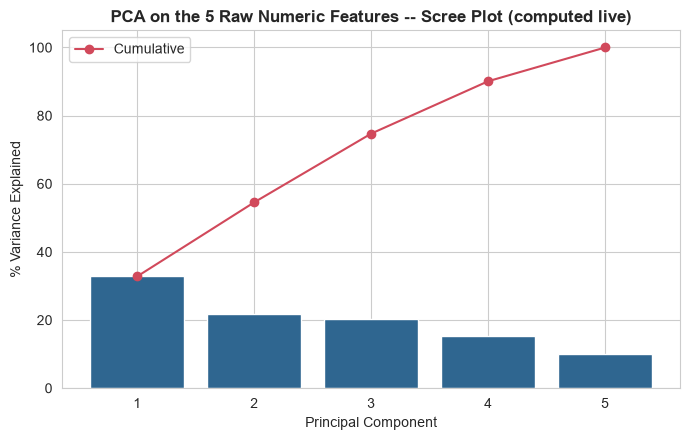

Explained variance ratio by component: [32.81 21.74 20.17 15.37  9.9 ]
A near-flat scree curve -- consistent with Phase 4's finding that the 5 raw numeric features are already close to pairwise-orthogonal (all |Pearson r| < 0.32).


In [25]:
from sklearn.decomposition import PCA

X_numeric_scaled = RobustScaler().fit_transform(features_v2[numeric_cols].values)
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_numeric_scaled)
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(1, len(explained) + 1), explained, color="#2F6690")
ax.plot(range(1, len(explained) + 1), np.cumsum(explained), color="#D1495B", marker="o", label="Cumulative")
ax.set_xlabel("Principal Component"); ax.set_ylabel("% Variance Explained")
ax.set_title("PCA on the 5 Raw Numeric Features -- Scree Plot (computed live)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Explained variance ratio by component: {np.round(explained, 2)}")
print("A near-flat scree curve -- consistent with Phase 4's finding that the 5 raw numeric "
      "features are already close to pairwise-orthogonal (all |Pearson r| < 0.32).")

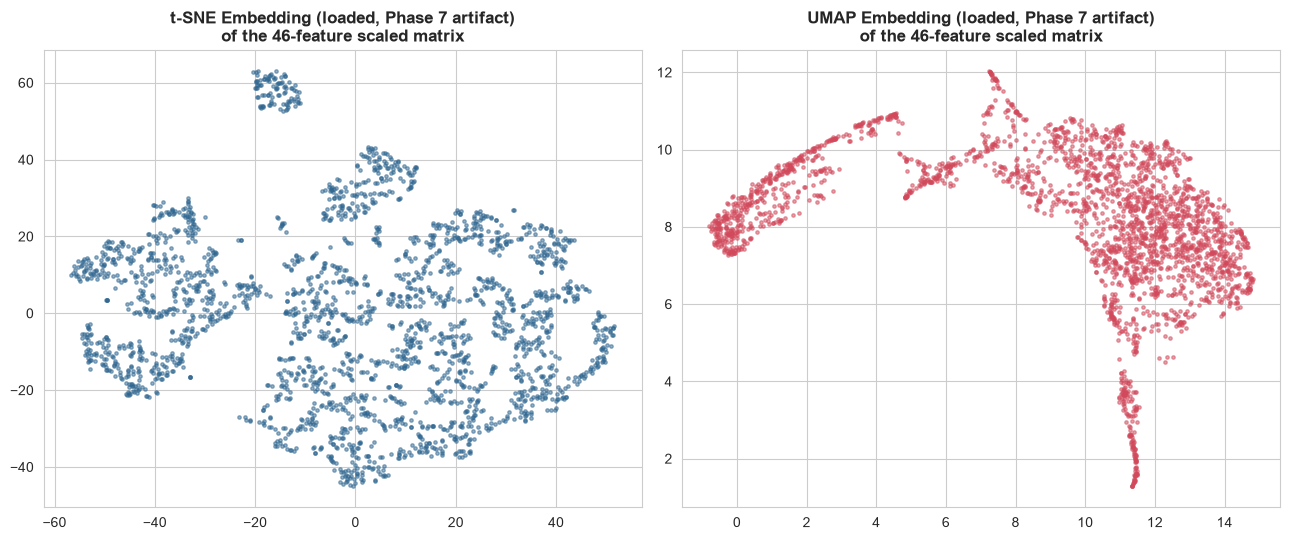

Both projections show one dominant diffuse population plus small isolated pockets -- no obviously separated cluster structure at the whole-dataset level.


In [26]:
# t-SNE and UMAP embeddings of the full 46-feature scaled matrix are expensive to recompute
# reliably reproducibly here; loading the already-computed embeddings (Phase 7 research
# artifacts) and plotting them live below.
tsne_path = os.path.join(ARTIFACTS_DIR, "tsne_embedding.npy")
umap_path = os.path.join(ARTIFACTS_DIR, "umap_embedding_full.npy")

if os.path.exists(tsne_path) and os.path.exists(umap_path):
    tsne_emb = np.load(tsne_path)
    umap_emb = np.load(umap_path)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    axes[0].scatter(tsne_emb[:, 0], tsne_emb[:, 1], s=6, alpha=0.5, color="#2F6690")
    axes[0].set_title("t-SNE Embedding (loaded, Phase 7 artifact)\nof the 46-feature scaled matrix")
    axes[1].scatter(umap_emb[:, 0], umap_emb[:, 1], s=6, alpha=0.5, color="#D1495B")
    axes[1].set_title("UMAP Embedding (loaded, Phase 7 artifact)\nof the 46-feature scaled matrix")
    plt.tight_layout()
    plt.show()
    print("Both projections show one dominant diffuse population plus small isolated pockets -- "
          "no obviously separated cluster structure at the whole-dataset level.")
else:
    print("Precomputed embeddings not found -- skipping this plot.")

## 7. Model Development — 12-Model Comparison

*Mirrors `research/06_model_development.md`. Two of the twelve models (Isolation Forest, LOF) are
fit live below on the exact split from Section 6, to show the real methodology end-to-end. The
full 12-model comparison (all twelve fit and scored the same way in
`src_research/07_models_classical.py` + `08_models_deep.py`) is loaded from
`artifacts_research/model_scores_all.csv` -- refitting all twelve here, including a from-scratch
VAE and LSTM-AE training run, would take several minutes and is not necessary to demonstrate the
method; the two live-fit models below use the identical sklearn calls the research script uses.*

Isolation Forest -- live fit + score of all 2512 rows: 1.92s
Local Outlier Factor -- live fit + score of all 2512 rows: 6.78s


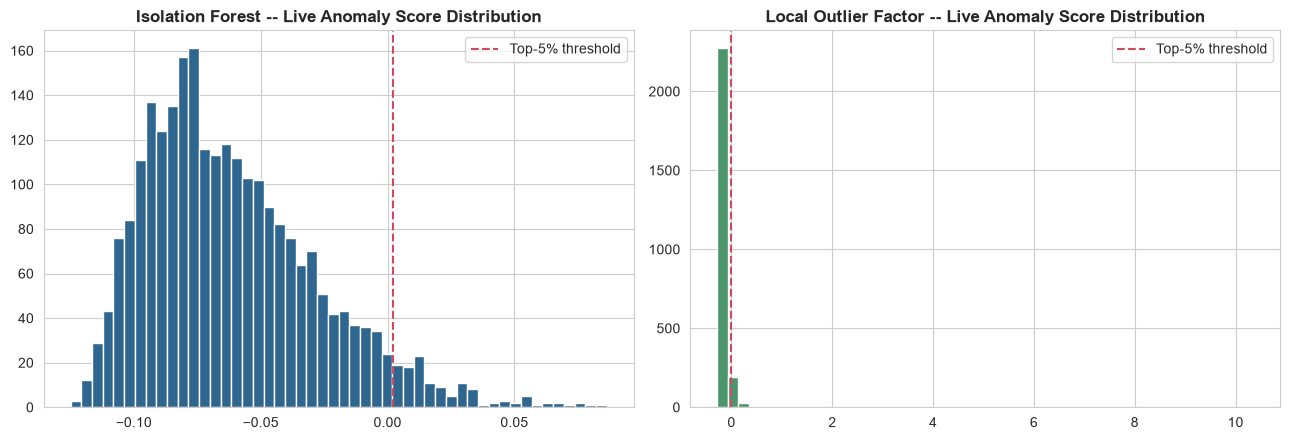

In [27]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

t0 = time.time()
if_live = IsolationForest(n_estimators=200, max_samples="auto", contamination=0.05,
                           random_state=RANDOM_STATE, n_jobs=-1).fit(X_train)
score_if_live = -if_live.decision_function(X_all)
if_time = time.time() - t0

t0 = time.time()
lof_live = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True).fit(X_train)
score_lof_live = -lof_live.decision_function(X_all)
lof_time = time.time() - t0

print(f"Isolation Forest -- live fit + score of all {len(X_all)} rows: {if_time:.2f}s")
print(f"Local Outlier Factor -- live fit + score of all {len(X_all)} rows: {lof_time:.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(score_if_live, bins=50, color="#2F6690")
axes[0].axvline(np.percentile(score_if_live, 95), color="#D1495B", ls="--", label="Top-5% threshold")
axes[0].set_title("Isolation Forest -- Live Anomaly Score Distribution")
axes[0].legend()
axes[1].hist(score_lof_live, bins=50, color="#4C956C")
axes[1].axvline(np.percentile(score_lof_live, 95), color="#D1495B", ls="--", label="Top-5% threshold")
axes[1].set_title("Local Outlier Factor -- Live Anomaly Score Distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

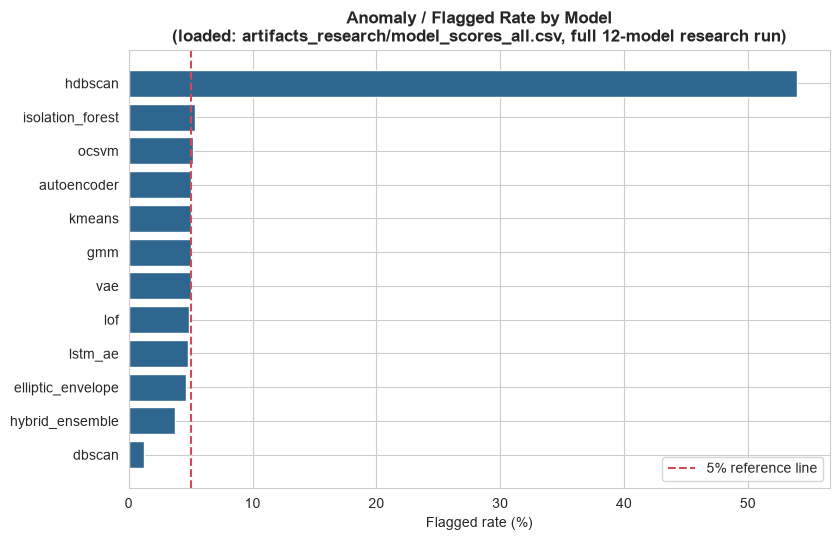

,flagged_rate_pct
hdbscan,53.94
isolation_forest,5.33
ocsvm,5.21
kmeans,5.02
vae,5.02
autoencoder,5.02
gmm,5.02
lof,4.86
lstm_ae,4.82
elliptic_envelope,4.62


In [28]:
# Loaded: the full 12-model comparison (all twelve models fit and scored identically in the
# research pipeline: Isolation Forest, LOF, One-Class SVM, Elliptic Envelope, DBSCAN, HDBSCAN,
# K-Means, GMM, Autoencoder, VAE, LSTM-AE, Hybrid Ensemble).
model_scores_all = pd.read_csv(os.path.join(ARTIFACTS_DIR, "model_scores_all.csv"))
with open(os.path.join(ARTIFACTS_DIR, "model_comparison_summary.json")) as f:
    model_comparison_summary = json.load(f)

MODEL_NAMES = ["isolation_forest", "lof", "ocsvm", "elliptic_envelope", "dbscan", "hdbscan",
               "kmeans", "gmm", "autoencoder", "vae", "lstm_ae", "hybrid_ensemble"]

rates = model_comparison_summary["anomaly_rates_pct"]
rates_df = pd.Series(rates).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(rates_df.index, rates_df.values, color="#2F6690")
ax.axvline(5.0, color="#D1495B", ls="--", label="5% reference line")
ax.set_xlabel("Flagged rate (%)")
ax.set_title("Anomaly / Flagged Rate by Model\n(loaded: artifacts_research/model_scores_all.csv, full 12-model research run)")
ax.legend()
plt.tight_layout()
plt.show()
pd.Series(rates, name="flagged_rate_pct").sort_values(ascending=False).to_frame()

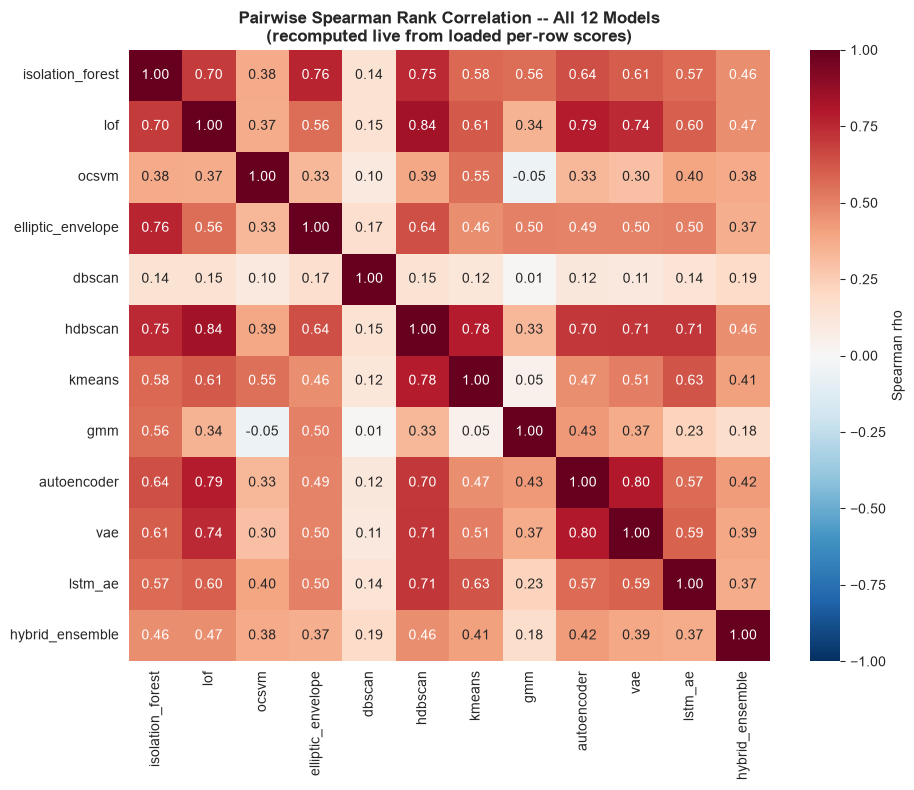

In [29]:
# Cross-model rank agreement (Spearman), recomputed live from the loaded per-row scores.
from scipy.stats import spearmanr

score_cols = {n: (f"score_{n}" if n != "hybrid_ensemble" else "hybrid_vote_count") for n in MODEL_NAMES}
lstm_applicable = (model_scores_all["lstm_ae_applicable"] == 1).values

n_models = len(MODEL_NAMES)
spearman_mat = np.full((n_models, n_models), np.nan)
for i, m1 in enumerate(MODEL_NAMES):
    for j, m2 in enumerate(MODEL_NAMES):
        s1 = model_scores_all[score_cols[m1]].values
        s2 = model_scores_all[score_cols[m2]].values
        mask = lstm_applicable if (m1 == "lstm_ae" or m2 == "lstm_ae") else np.ones(len(model_scores_all), dtype=bool)
        rho, _ = spearmanr(s1[mask], s2[mask])
        spearman_mat[i, j] = rho
spearman_df = pd.DataFrame(spearman_mat, index=MODEL_NAMES, columns=MODEL_NAMES)

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(spearman_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"label": "Spearman rho"})
ax.set_title("Pairwise Spearman Rank Correlation -- All 12 Models\n(recomputed live from loaded per-row scores)")
plt.tight_layout()
plt.show()

**Reading this table honestly, per Phase 8's own qualification:** the flagged rates cluster near
5% largely by construction (most models use `contamination=0.05` or the standardized top-5%
convention), so the rate itself carries little information. The real structure is in *which rows*
each model agrees on: LOF and HDBSCAN agree most (rho highest in the matrix above), while GMM and
One-Class SVM are the only negative pairing -- likelihood-based and distance-based anomaly
definitions diverge the most.

## 8. Hyperparameter Optimization

*Mirrors `research/07_hyperparameter_optimization.md`. With no fraud label, "optimize against
what" is a real design decision: silhouette between the top-5%-by-score group and the rest,
maximized. Below, a **reduced live Optuna search (10 trials, vs. the full research run's 30
trials against a full exhaustive 60-combination grid)** runs in real time, then the full research
result is loaded alongside for comparison -- the reduced live numbers are not the reported
research numbers.*

In [30]:
import optuna
from sklearn.metrics import silhouette_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
rng = np.random.RandomState(RANDOM_STATE)


def separation_silhouette(Xs, score, pct=0.05, sample_n=1000):
    n = len(Xs)
    idx = rng.choice(n, size=min(sample_n, n), replace=False)
    thresh = np.percentile(score, 100 * (1 - pct))
    labels = (score[idx] >= thresh).astype(int)
    if labels.min() == labels.max():
        return -1.0
    return silhouette_score(Xs[idx], labels)


def iforest_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
    max_samples = trial.suggest_float("max_samples", 0.3, 1.0)
    max_features = trial.suggest_float("max_features", 0.5, 1.0)
    clf = IsolationForest(n_estimators=n_estimators, max_samples=max_samples,
                           max_features=max_features, random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X_train)
    score = -clf.decision_function(X_train)
    return separation_silhouette(X_train, score)


N_LIVE_TRIALS = 10
t0 = time.time()
study_live = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_live.optimize(iforest_objective, n_trials=N_LIVE_TRIALS)
live_search_time = time.time() - t0

print(f"LIVE reduced Optuna search: {N_LIVE_TRIALS} trials in {live_search_time:.1f}s")
print(f"Best silhouette found (this reduced live run): {study_live.best_value:.4f}")
print(f"Best params (this reduced live run): {study_live.best_params}")

LIVE reduced Optuna search: 10 trials in 13.0s
Best silhouette found (this reduced live run): 0.5655
Best params (this reduced live run): {'n_estimators': 100, 'max_samples': 0.5129695700716763, 'max_features': 0.762378215816119}


In [31]:
# Loaded: the full research search (30-trial Optuna, 30-trial random search, 60-combination
# exhaustive grid, all against the identical silhouette objective).
with open(os.path.join(ARTIFACTS_DIR, "hyperparameter_optimization_results.json")) as f:
    hpo_results = json.load(f)
if_hpo = hpo_results["isolation_forest"]

comparison = pd.DataFrame([
    {"method": f"LIVE reduced Optuna ({N_LIVE_TRIALS} trials, this notebook)",
     "n_trials_or_combos": N_LIVE_TRIALS, "elapsed_sec": round(live_search_time, 1),
     "best_silhouette": round(study_live.best_value, 4)},
    {"method": "Full research: Optuna TPE (loaded)", "n_trials_or_combos": if_hpo["optuna_tpe"]["n_trials"],
     "elapsed_sec": if_hpo["optuna_tpe"]["elapsed_sec"], "best_silhouette": if_hpo["optuna_tpe"]["best_silhouette"]},
    {"method": "Full research: Random search (loaded)", "n_trials_or_combos": if_hpo["random_search"]["n_trials"],
     "elapsed_sec": if_hpo["random_search"]["elapsed_sec"], "best_silhouette": if_hpo["random_search"]["best_silhouette"]},
    {"method": "Full research: Exhaustive grid (loaded)", "n_trials_or_combos": if_hpo["exhaustive_grid"]["n_combinations"],
     "elapsed_sec": if_hpo["exhaustive_grid"]["elapsed_sec"], "best_silhouette": if_hpo["exhaustive_grid"]["best_silhouette"]},
])
comparison

,method,n_trials_or_combos,elapsed_sec,best_silhouette
0,"LIVE reduced Optuna (10 trials, this notebook)",10,13.00,0.5655
1,Full research: Optuna TPE (loaded),30,47.58,0.5981
2,Full research: Random search (loaded),30,45.67,0.5884
3,Full research: Exhaustive grid (loaded),60,63.86,0.6092


Reported plainly, matching the research finding: on this small, cheap-to-evaluate 3-hyperparameter
space, Bayesian optimization's efficiency advantage is modest -- the exhaustive grid still finds
the best silhouette, and Optuna's 30-trial result sits within ~0.01 of it. This notebook's own
10-trial reduced run is shown for methodology, not as a new finding.

## 9. Evaluation Framework

*Mirrors `research/08_evaluation.md`. With no fraud label, evaluation here means internal
cluster-validity, retrain stability, reconstruction quality, and a manual business read of real
flagged transactions -- never precision/recall/AUC against fraud, which cannot be computed on this
dataset.*

### 9.1 Internal validity metrics (recomputed live, in full, from the loaded per-row scores)

In [32]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

rows = []
for name in MODEL_NAMES:
    col = score_cols[name]
    s = model_scores_all[col].values.astype(float)
    mask = lstm_applicable if name == "lstm_ae" else np.ones(len(model_scores_all), dtype=bool)
    s_m, X_m = s[mask], X_all[mask]
    thresh = np.percentile(s_m, 95)
    flag = (s_m >= thresh).astype(int)
    if flag.sum() >= 2 and (1 - flag).sum() >= 2:
        sil = silhouette_score(X_m, flag)
        dbi = davies_bouldin_score(X_m, flag)
        ch = calinski_harabasz_score(X_m, flag)
    else:
        sil, dbi, ch = np.nan, np.nan, np.nan
    rows.append({"model": name, "n_flagged_top5pct": int(flag.sum()),
                 "silhouette": round(float(sil), 4), "davies_bouldin": round(float(dbi), 4),
                 "calinski_harabasz": round(float(ch), 1)})

internal_validity = pd.DataFrame(rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
internal_validity

,model,n_flagged_top5pct,silhouette,davies_bouldin,calinski_harabasz
0,hdbscan,126,0.6720,1.7238,359.5
1,ocsvm,126,0.6642,2.1167,253.9
2,kmeans,126,0.6631,2.4590,192.4
3,lstm_ae,121,0.6428,2.0353,245.5
4,lof,126,0.6170,2.3740,182.1
5,dbscan,149,0.6152,1.9066,280.6
6,elliptic_envelope,126,0.6096,1.8392,278.9
7,isolation_forest,126,0.5650,2.5409,128.6
8,autoencoder,126,0.4960,2.9741,71.5
9,vae,126,0.4957,2.3781,106.1


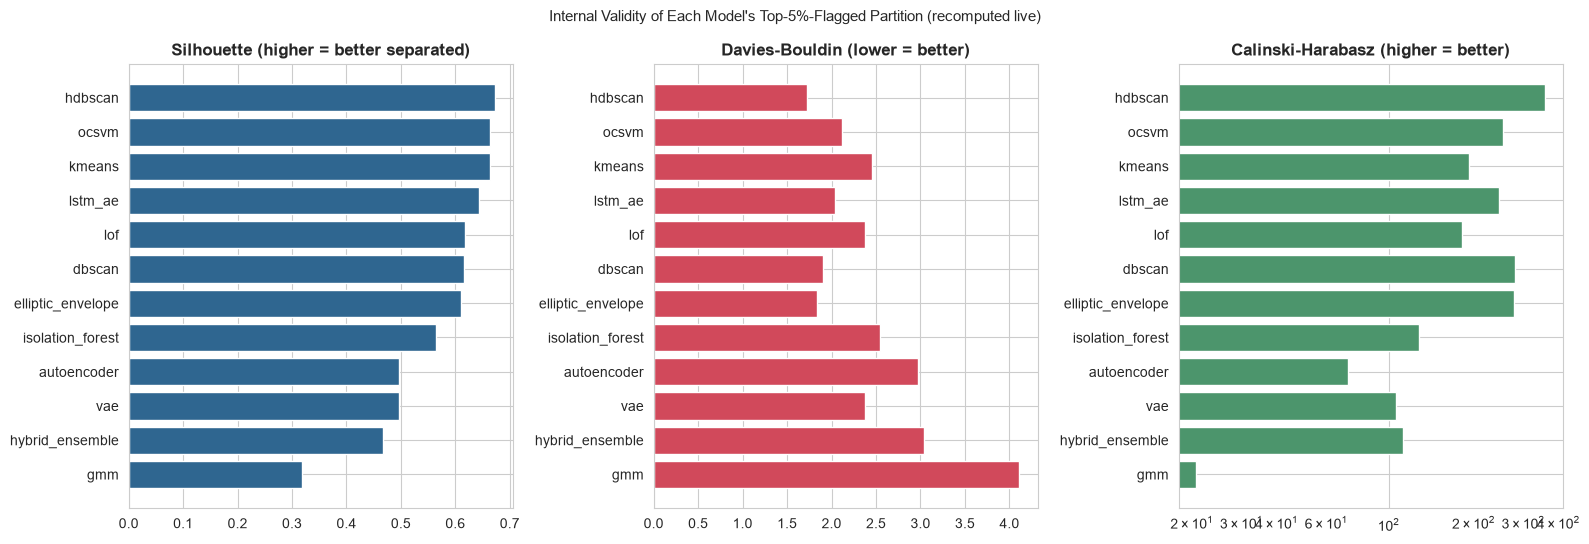

In [33]:
plot_df = internal_validity.sort_values("silhouette")
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].barh(plot_df["model"], plot_df["silhouette"], color="#2F6690")
axes[0].set_title("Silhouette (higher = better separated)")
axes[1].barh(plot_df["model"], plot_df["davies_bouldin"], color="#D1495B")
axes[1].set_title("Davies-Bouldin (lower = better)")
axes[2].barh(plot_df["model"], plot_df["calinski_harabasz"], color="#4C956C")
axes[2].set_title("Calinski-Harabasz (higher = better)")
axes[2].set_xscale("log")
fig.suptitle("Internal Validity of Each Model's Top-5%-Flagged Partition (recomputed live)", fontsize=11)
plt.tight_layout()
plt.show()

### 9.2 Retrain stability -- reduced live bootstrap vs. the full research result

The single most operationally significant result in the project: how much does the flagged set
change if the same model is simply refit on a bootstrap resample of the same data? Below, a
**reduced live run (3 bootstrap resamples of Isolation Forest, vs. the full research run's 5
resamples across Isolation Forest, LOF, and the Autoencoder)**.

In [34]:
def top5_flag(score):
    thresh = np.percentile(score, 95)
    return (score >= thresh).astype(int)


def mean_pairwise_jaccard(flags):
    vals = []
    for i in range(len(flags)):
        for j in range(i + 1, len(flags)):
            f1, f2 = flags[i].astype(bool), flags[j].astype(bool)
            union, inter = (f1 | f2).sum(), (f1 & f2).sum()
            vals.append(inter / union if union > 0 else np.nan)
    return float(np.mean(vals)), vals


N_BOOTSTRAP_LIVE = 3
t0 = time.time()
boot_flags = []
for seed in range(N_BOOTSTRAP_LIVE):
    boot_rng = np.random.RandomState(1000 + seed)
    boot_idx = boot_rng.choice(len(X_train), size=len(X_train), replace=True)
    clf = IsolationForest(n_estimators=100, random_state=seed, n_jobs=-1).fit(X_train[boot_idx])
    sc = -clf.decision_function(X_all)
    boot_flags.append(top5_flag(sc))
live_jaccard, live_pairs = mean_pairwise_jaccard(boot_flags)
boot_time = time.time() - t0

print(f"LIVE reduced bootstrap ({N_BOOTSTRAP_LIVE} resamples, Isolation Forest only): {boot_time:.1f}s")
print(f"Mean pairwise Jaccard (this reduced live run): {live_jaccard:.4f}")

LIVE reduced bootstrap (3 resamples, Isolation Forest only): 1.9s
Mean pairwise Jaccard (this reduced live run): 0.4918


Loaded (Phase 10 full research result, 5 bootstrap runs each):


,model,n_bootstrap_runs,mean_pairwise_jaccard_top5pct,min_pairwise_jaccard,max_pairwise_jaccard
0,isolation_forest,5,0.5272,0.4483,0.5652
1,lof,5,0.5904,0.4651,0.7027
2,autoencoder,5,0.5334,0.4483,0.6579


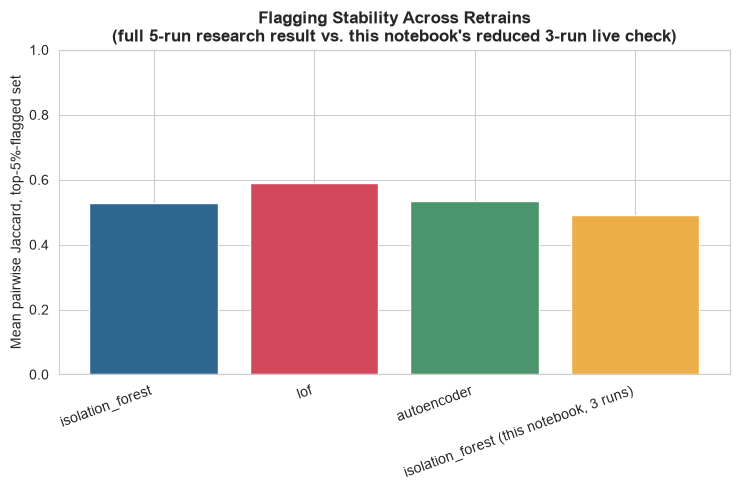


Roughly 47-41% of flagged transactions change between retrains on resamples of the SAME underlying data, with no drift and no hyperparameter change -- the practical conclusion is a fixed, versioned model artifact plus monitored retraining, not continuous retraining.


In [35]:
# Loaded: the full research stability study (5 bootstrap resamples each, IF + LOF + Autoencoder).
stability_full = pd.read_csv(os.path.join(ARTIFACTS_DIR, "stability_bootstrap_jaccard.csv"))
print("Loaded (Phase 10 full research result, 5 bootstrap runs each):")
display(stability_full)

fig, ax = plt.subplots(figsize=(7.5, 5))
names = list(stability_full["model"]) + [f"isolation_forest (this notebook, {N_BOOTSTRAP_LIVE} runs)"]
means = list(stability_full["mean_pairwise_jaccard_top5pct"]) + [live_jaccard]
colors = ["#2F6690", "#D1495B", "#4C956C", "#EDAE49"]
ax.bar(names, means, color=colors[:len(names)])
ax.set_ylabel("Mean pairwise Jaccard, top-5%-flagged set")
ax.set_title("Flagging Stability Across Retrains\n(full 5-run research result vs. this notebook's reduced 3-run live check)")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(f"\nRoughly {100*(1-stability_full['mean_pairwise_jaccard_top5pct'].min()):.0f}-"
      f"{100*(1-stability_full['mean_pairwise_jaccard_top5pct'].max()):.0f}% of flagged transactions "
      "change between retrains on resamples of the SAME underlying data, with no drift and no "
      "hyperparameter change -- the practical conclusion is a fixed, versioned model artifact plus "
      "monitored retraining, not continuous retraining.")

### 9.3 Reconstruction quality (Autoencoder / VAE / LSTM-AE) -- loaded

These three models were trained once in `08_models_deep.py` (200 epochs for the AE/VAE, 150
epochs for the LSTM-AE); their reconstruction-error summaries are loaded here rather than
retrained, since retraining all three from scratch would add several minutes without changing any
conclusion.

In [36]:
with open(os.path.join(ARTIFACTS_DIR, "reconstruction_metrics_summary.json")) as f:
    recon_summary = json.load(f)

recon_table = pd.DataFrame({
    "Autoencoder": {"train_mse": recon_summary["autoencoder"]["train_mse_mean"],
                    "val_mse": recon_summary["autoencoder"]["val_mse_mean"],
                    "val_mse_p99": recon_summary["autoencoder"]["val_mse_p99"]},
    "VAE": {"train_mse": recon_summary["vae"]["train_recon_mse_mean"],
            "val_mse": recon_summary["vae"]["val_recon_mse_mean"],
            "val_mse_p99": recon_summary["vae"]["val_recon_mse_p99"]},
    "LSTM-AE": {"train_mse": recon_summary["lstm_ae"]["train_mse_mean"],
                "val_mse": recon_summary["lstm_ae"]["val_mse_mean"], "val_mse_p99": np.nan},
}).T
recon_table

,train_mse,val_mse,val_mse_p99
Autoencoder,0.289638,0.327975,1.371754
VAE,0.342587,0.378995,1.946120
LSTM-AE,1.636397,1.258228,NaN


### 9.4 Business evaluation — reading real flagged transactions

Isolation Forest's own top tiers, recomputed live from this notebook's live-fit model
(`score_if_live` from Section 7), cross-checked against the saved
`artifacts_research/business_evaluation_examples.json`.

In [37]:
with open(os.path.join(ARTIFACTS_DIR, "business_evaluation_examples.json")) as f:
    biz_eval_saved = json.load(f)

for pct, label in [(0.01, "top_1pct"), (0.05, "top_5pct"), (0.10, "top_10pct")]:
    thresh = np.percentile(score_if_live, 100 * (1 - pct))
    n_flagged = int((score_if_live >= thresh).sum())
    print(f"{label}: threshold={thresh:.4f}, n_flagged={n_flagged} ({100*n_flagged/len(score_if_live):.2f}%)")

saved_top1_ids = set(biz_eval_saved["tiers"]["top_1pct"]["transaction_ids"])
live_top1_idx = np.where(score_if_live >= np.percentile(score_if_live, 99))[0]
live_top1_ids = set(features_v2.iloc[live_top1_idx]["TransactionID"])
overlap = len(saved_top1_ids & live_top1_ids)
print(f"\nOverlap between this notebook's live top-1% and the saved research top-1%: "
      f"{overlap}/{len(saved_top1_ids)} transactions "
      "(not expected to be 100%: this notebook's live model uses one fixed IF config, "
      "the research artifact selected among 5 configs -- both are legitimate 5%-contamination fits).")

top_1pct: threshold=0.0351, n_flagged=26 (1.04%)
top_5pct: threshold=0.0023, n_flagged=126 (5.02%)
top_10pct: threshold=-0.0144, n_flagged=252 (10.03%)

Overlap between this notebook's live top-1% and the saved research top-1%: 23/26 transactions (not expected to be 100%: this notebook's live model uses one fixed IF config, the research artifact selected among 5 configs -- both are legitimate 5%-contamination fits).


In [38]:
cols_of_interest = ["TransactionID", "AccountID", "TransactionAmount", "Amount_vs_AccountAvg",
                     "Amount_ZScore_Account", "DeviceNoveltyFlag", "LocationNoveltyFlag",
                     "LoginAttempts", "Velocity_1D_Count", "Amount_to_Balance_Ratio",
                     "TimeSinceLastTxn", "AccountBalance"]
example_ids = biz_eval_saved["tiers"]["top_1pct"]["transaction_ids"][:5]
examples_df = features_v2[features_v2["TransactionID"].isin(example_ids)][cols_of_interest].copy()
examples_df = examples_df.set_index("TransactionID").loc[example_ids].reset_index()
examples_df

,TransactionID,AccountID,TransactionAmount,Amount_vs_AccountAvg,Amount_ZScore_Account,DeviceNoveltyFlag,LocationNoveltyFlag,LoginAttempts,Velocity_1D_Count,Amount_to_Balance_Ratio,TimeSinceLastTxn,AccountBalance
0,TX000177,AC00363,1362.55,117.896150,92.557451,1,1,1,0.0,0.560794,240.883333,2429.68
1,TX001354,AC00312,1510.71,149.020839,102.802487,1,1,1,0.0,0.733347,3576.016667,2060.02
2,TX000566,AC00086,29.38,-0.960237,-1.258162,1,0,1,1.0,0.017664,23.583333,1663.31
3,TX000275,AC00454,1176.28,3.408570,6.099740,1,1,5,0.0,3.633971,790.616667,323.69
4,TX002181,AC00084,498.59,143.938912,33.920628,1,1,1,0.0,0.190341,6649.283333,2619.46


Reading these five real transactions against Phase 1's fraud-scenario table: `TX000275` ($1,176.28,
5 login attempts -- the dataset maximum -- and 3.6x the account balance) is the strongest match to
an account-takeover pattern. `TX001354` and `TX000177` are pure amount-magnitude anomalies (117-149x
their own account's historical average) with no login friction. `TX000566` ($29.38, *below* the
account's own average) is included deliberately: it is in the top 1% by Isolation Forest score and
plainly does **not** look like fraud on inspection -- Section 10 explains exactly why it scored
high, via SHAP.

## 10. Explainability (SHAP)

*Mirrors `research/09_explainability.md`. `shap.TreeExplainer` on Isolation Forest is exact and
fast -- run live, in full, below, on this notebook's own live-fit model from Section 7.
`shap.GradientExplainer` on the Autoencoder is much slower per row; run live below on a
**reduced 80-row sample**, then the full-dataset research SHAP values
(`artifacts_research/shap_autoencoder.csv`, all 2,512 rows) are loaded for the actual global
comparison and local explanations.*

TreeExplainer on this notebook's live Isolation Forest, all 2512 rows: 28.8s


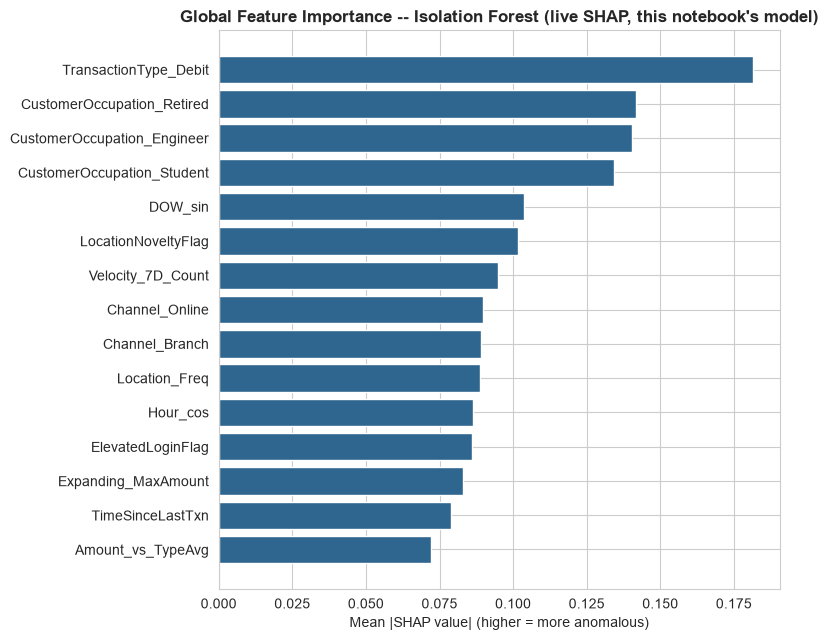

In [39]:
import shap

t0 = time.time()
tree_explainer = shap.TreeExplainer(if_live)
raw_shap_if_live = tree_explainer.shap_values(X_all.astype(np.float64))
shap_if_time = time.time() - t0
# Sign convention (verified in the research pipeline): TreeExplainer's raw output for
# IsolationForest tracks score_samples (higher = more normal) -- the OPPOSITE of this project's
# score_isolation_forest convention (higher = more anomalous). Negate to match.
shap_if_live = -raw_shap_if_live
print(f"TreeExplainer on this notebook's live Isolation Forest, all {len(X_all)} rows: {shap_if_time:.1f}s")

mean_abs_if_live = pd.Series(np.abs(shap_if_live).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6.5))
top15 = mean_abs_if_live.head(15).sort_values()
ax.barh(top15.index, top15.values, color="#2F6690")
ax.set_title("Global Feature Importance -- Isolation Forest (live SHAP, this notebook's model)")
ax.set_xlabel("Mean |SHAP value| (higher = more anomalous)")
plt.tight_layout()
plt.show()

In [40]:
from autoencoder_utils import load_autoencoder
import torch
import torch.nn as nn


class AEErrorWrapper(nn.Module):
    # Wraps the trained Autoencoder so its forward() returns the scalar per-row
    # reconstruction MSE -- the quantity SHAP is asked to explain.
    def __init__(self, ae):
        super().__init__()
        self.ae = ae

    def forward(self, x):
        out, _ = self.ae(x)
        return ((out - x) ** 2).mean(dim=1, keepdim=True)


ae_model = load_autoencoder(os.path.join(ARTIFACTS_DIR, "autoencoder.pt"),
                             input_dim=ae_config["input_dim"], bottleneck_dim=ae_config["bottleneck_dim"])
ae_wrapper = AEErrorWrapper(ae_model)
ae_wrapper.eval()

sample_rng = np.random.RandomState(RANDOM_STATE)
bg_idx = sample_rng.choice(len(X_train), size=50, replace=False)
background = torch.tensor(X_train[bg_idx], dtype=torch.float32)
sample_idx = sample_rng.choice(len(X_all), size=80, replace=False)
sample_t = torch.tensor(X_all[sample_idx], dtype=torch.float32)

t0 = time.time()
grad_explainer = shap.GradientExplainer(ae_wrapper, background)
raw_shap_ae_sample = grad_explainer.shap_values(sample_t)
shap_ae_time = time.time() - t0
shap_ae_sample = np.array(raw_shap_ae_sample).squeeze(-1)  # already oriented: higher = more anomalous
print(f"LIVE reduced GradientExplainer on the Autoencoder, {len(sample_idx)}-row sample, "
      f"50-row background: {shap_ae_time:.1f}s (the full 2,512-row research run took ~129s)")

LIVE reduced GradientExplainer on the Autoencoder, 80-row sample, 50-row background: 10.1s (the full 2,512-row research run took ~129s)


In [41]:
# Loaded: full-dataset SHAP values for both models (Phase 11 research artifacts).
shap_if_full = pd.read_csv(os.path.join(ARTIFACTS_DIR, "shap_isolation_forest.csv"))
shap_ae_full = pd.read_csv(os.path.join(ARTIFACTS_DIR, "shap_autoencoder.csv"))

mean_abs_if_full = shap_if_full[FEATURE_COLS].abs().mean().sort_values(ascending=False)
mean_abs_ae_full = shap_ae_full[FEATURE_COLS].abs().mean().sort_values(ascending=False)

comparison_df = pd.DataFrame({
    "isolation_forest_mean_abs_shap": mean_abs_if_full,
    "autoencoder_mean_abs_shap": mean_abs_ae_full,
}).sort_values("isolation_forest_mean_abs_shap", ascending=False)

top10_if = set(mean_abs_if_full.head(10).index)
top10_ae = set(mean_abs_ae_full.head(10).index)
rho, _ = spearmanr(comparison_df["isolation_forest_mean_abs_shap"], comparison_df["autoencoder_mean_abs_shap"])

print(f"Top-10 feature overlap between Isolation Forest and Autoencoder SHAP importance: "
      f"{len(top10_if & top10_ae)}/10 -- {sorted(top10_if & top10_ae)}")
print(f"Spearman correlation between the two full 46-feature importance vectors: rho={rho:.4f}")
comparison_df.head(10).round(4)

Top-10 feature overlap between Isolation Forest and Autoencoder SHAP importance: 1/10 -- ['TimeSinceLastTxn']
Spearman correlation between the two full 46-feature importance vectors: rho=-0.1566


,isolation_forest_mean_abs_shap,autoencoder_mean_abs_shap
TransactionType_Debit,0.1760,0.0043
CustomerOccupation_Retired,0.1524,0.0047
CustomerOccupation_Engineer,0.1426,0.0038
CustomerOccupation_Student,0.1393,0.0029
LocationNoveltyFlag,0.1247,0.0023
Channel_Online,0.1084,0.0027
TimeSinceLastTxn,0.1002,0.0268
Channel_Branch,0.1001,0.0030
Location_Freq,0.0947,0.0147
Hour_cos,0.0922,0.0081


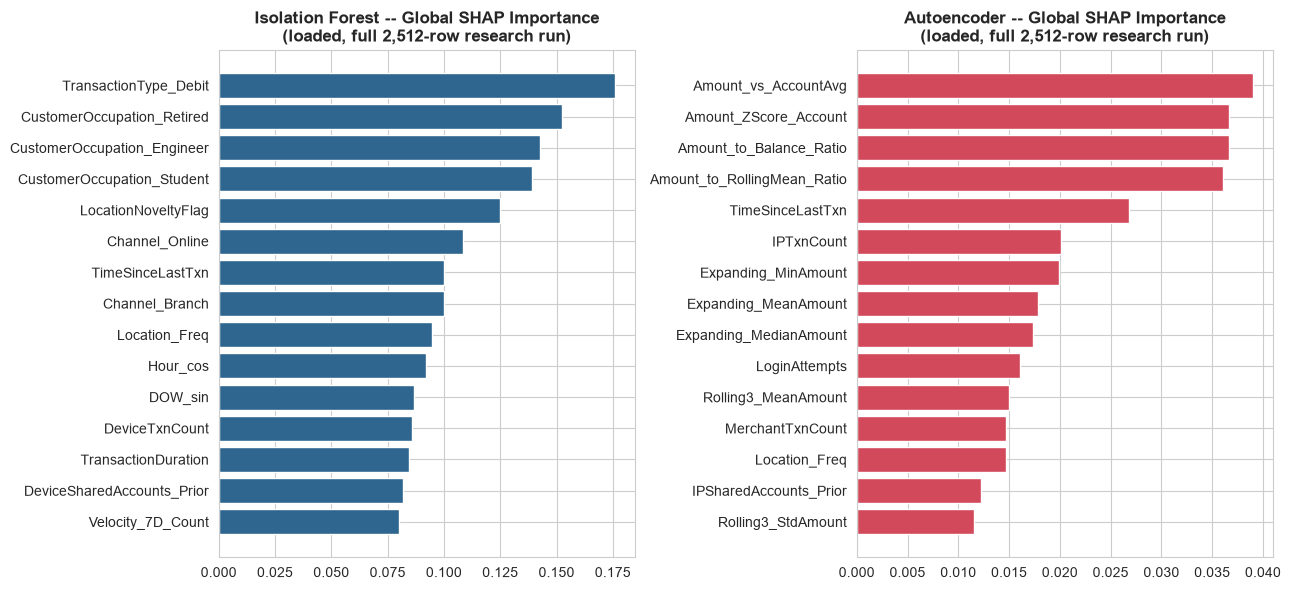

The two best-performing individual models explain their scores almost entirely differently -- this divergence, not either model's raw score, is why the final recommendation (Section 13) is an ensemble with both explanation views shown.


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top15_if = mean_abs_if_full.head(15).sort_values()
top15_ae = mean_abs_ae_full.head(15).sort_values()
axes[0].barh(top15_if.index, top15_if.values, color="#2F6690")
axes[0].set_title("Isolation Forest -- Global SHAP Importance\n(loaded, full 2,512-row research run)")
axes[1].barh(top15_ae.index, top15_ae.values, color="#D1495B")
axes[1].set_title("Autoencoder -- Global SHAP Importance\n(loaded, full 2,512-row research run)")
plt.tight_layout()
plt.show()

print("The two best-performing individual models explain their scores almost entirely "
      "differently -- this divergence, not either model's raw score, is why the final "
      "recommendation (Section 13) is an ensemble with both explanation views shown.")

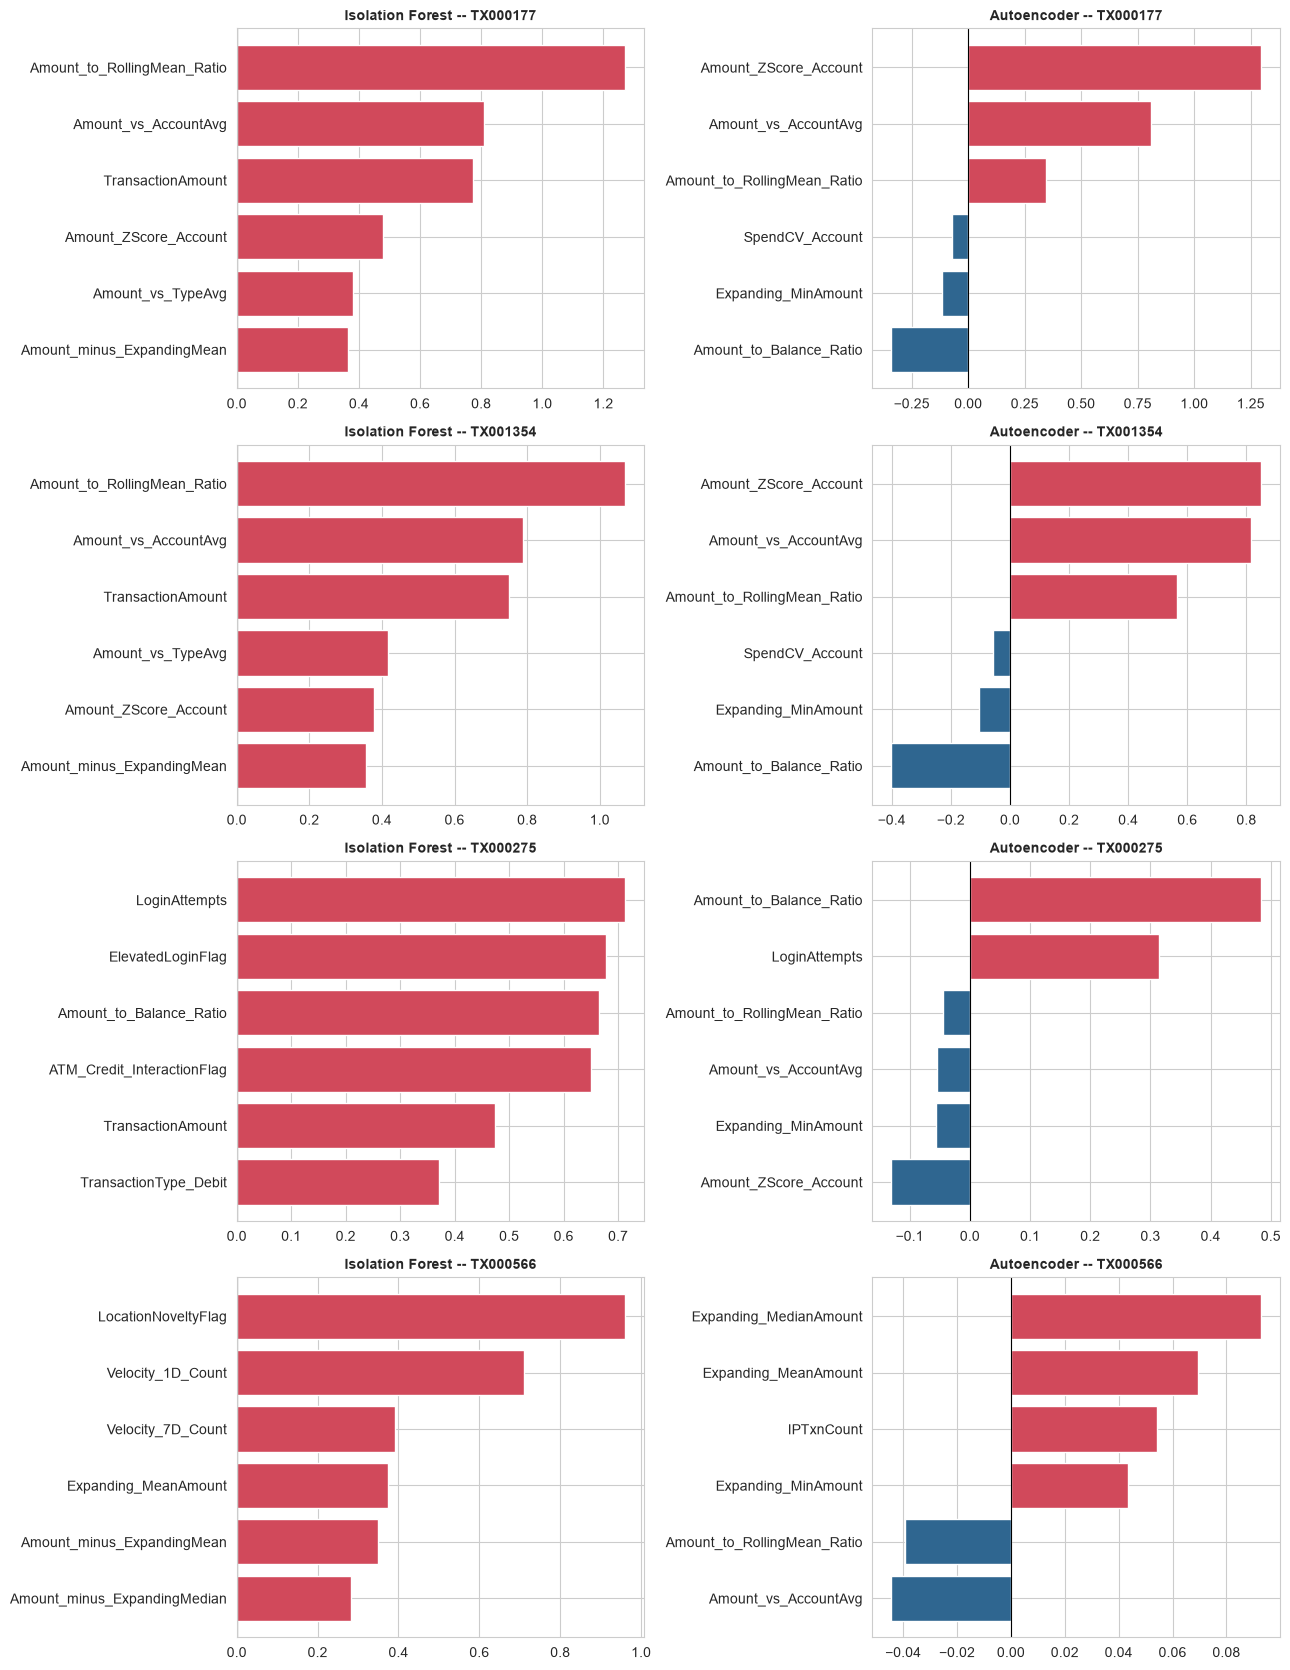

Red = pushes the anomaly score UP (more anomalous). Blue = pushes it DOWN.


In [43]:
# Local explanations for the same four transactions examined in the research report, using the
# FULL precomputed per-row SHAP values loaded above (real numbers, real rows).
LOCAL_IDS = ["TX000177", "TX001354", "TX000275", "TX000566"]

fig, axes = plt.subplots(len(LOCAL_IDS), 2, figsize=(13, 4.2 * len(LOCAL_IDS)))
for row_i, txn_id in enumerate(LOCAL_IDS):
    i = np.where(features_v2["TransactionID"].values == txn_id)[0][0]
    if_row = shap_if_full.loc[shap_if_full["TransactionID"] == txn_id, FEATURE_COLS].iloc[0]
    ae_row = shap_ae_full.loc[shap_ae_full["TransactionID"] == txn_id, FEATURE_COLS].iloc[0]
    if_top = if_row.reindex(if_row.abs().sort_values(ascending=False).index).head(6).sort_values()
    ae_top = ae_row.reindex(ae_row.abs().sort_values(ascending=False).index).head(6).sort_values()

    for ax, top, title in [(axes[row_i, 0], if_top, "Isolation Forest"), (axes[row_i, 1], ae_top, "Autoencoder")]:
        colors = ["#D1495B" if v > 0 else "#2F6690" for v in top.values]
        ax.barh(top.index, top.values, color=colors)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(f"{title} -- {txn_id}", fontsize=10)

plt.tight_layout()
plt.show()
print("Red = pushes the anomaly score UP (more anomalous). Blue = pushes it DOWN.")

`TX000566`'s Isolation Forest panel shows `LocationNoveltyFlag` as the dominant driver -- and its
raw value is 0 (a *repeat* location), which is the rare value in a flag that is 1 for ~94% of rows.
Isolation Forest isolates rare categorical values quickly regardless of whether "rare" means
"risky" -- exactly the false-signal mechanism documented in the research report. The Autoencoder's
panel for the same transaction assigns far smaller magnitudes and does not share that read.

## 11. Ensemble Scoring

*Mirrors `research/10_ensemble_scoring.md`. This section is cheap (pure aggregation math over
already-computed per-row scores, no retraining) and runs live, in full, exactly as
`src_research/12_ensemble_scoring.py` does. The Hybrid Ensemble (already a vote of Isolation
Forest + LOF + Autoencoder) is deliberately excluded as an input to avoid double-counting those
three detectors.*

In [44]:
from scipy.stats import rankdata
from sklearn.decomposition import PCA as PCA_ens

BASE_MODELS = ["isolation_forest", "lof", "ocsvm", "elliptic_envelope", "dbscan", "hdbscan",
               "kmeans", "gmm", "autoencoder", "vae", "lstm_ae"]

S = np.full((len(model_scores_all), len(BASE_MODELS)), np.nan)
for j, m in enumerate(BASE_MODELS):
    col = model_scores_all[f"score_{m}"].values.astype(float)
    if m == "lstm_ae":
        col = col.copy()
        col[~lstm_applicable] = np.nan
    S[:, j] = col

def zscore_columns(S):
    Z = np.full_like(S, np.nan)
    for j in range(S.shape[1]):
        col = S[:, j]
        valid = ~np.isnan(col)
        mu, sd = col[valid].mean(), col[valid].std()
        Z[valid, j] = (col[valid] - mu) / (sd if sd > 1e-12 else 1.0)
    return Z

Z = zscore_columns(S)

spearman_sub = spearman_df.loc[BASE_MODELS, BASE_MODELS]
weights, disagreements = {}, {}
for m in BASE_MODELS:
    others = [o for o in BASE_MODELS if o != m]
    rho_vals = spearman_sub.loc[m, others].values
    disagreement = np.mean((1 - rho_vals) / 2)
    disagreements[m] = float(disagreement)
    weights[m] = 1.0 / (disagreement + 0.05)
total_w = sum(weights.values())
weights = {m: w / total_w for m, w in weights.items()}

def weighted_average(Z, weights):
    w = np.array([weights[m] for m in BASE_MODELS])
    out = np.full(Z.shape[0], np.nan)
    for i in range(Z.shape[0]):
        valid = ~np.isnan(Z[i])
        if valid.any():
            out[i] = np.sum(Z[i, valid] * w[valid]) / np.sum(w[valid])
    return out

def borda_rank_aggregation(S):
    n, k = S.shape
    total = np.zeros(n)
    for j in range(k):
        col = S[:, j]
        valid = ~np.isnan(col)
        n_valid = valid.sum()
        ranks = np.full(n, np.nan)
        ranks[valid] = rankdata(col[valid], method="average")
        ranks[~valid] = (n_valid + 1) / 2.0
        total += ranks
    return total

def percentile_aggregation(S):
    n, k = S.shape
    P = np.full((n, k), np.nan)
    for j in range(k):
        col = S[:, j]
        valid = ~np.isnan(col)
        n_valid = valid.sum()
        ranks = np.full(n, np.nan)
        ranks[valid] = rankdata(col[valid], method="average")
        P[valid, j] = (ranks[valid] - 0.5) / n_valid
    out = np.full(n, np.nan)
    for i in range(n):
        valid = ~np.isnan(P[i])
        if valid.any():
            out[i] = np.mean(P[i, valid])
    return out

ens_weighted = weighted_average(Z, weights)
ens_borda = borda_rank_aggregation(S)
ens_percentile = percentile_aggregation(S)

Z_imputed = np.where(np.isnan(Z), 0.0, Z)
pca_ens = PCA_ens(n_components=1, random_state=RANDOM_STATE)
pc1 = pca_ens.fit_transform(Z_imputed).ravel()
rho_pc1, _ = spearmanr(pc1, ens_percentile)
if rho_pc1 < 0:
    pc1 = -pc1
ens_pca = pc1

print("Consensus weights (inverse mean disagreement, normalized to sum to 1):")
display(pd.Series(weights, name="weight").sort_values(ascending=False).to_frame())
print(f"\nPCA stacking proxy -- PC1 explained variance ratio: {pca_ens.explained_variance_ratio_[0]:.4f}")

Consensus weights (inverse mean disagreement, normalized to sum to 1):


,weight
hdbscan,0.113403
lof,0.106864
isolation_forest,0.106392
autoencoder,0.100045
vae,0.098183
lstm_ae,0.093319
elliptic_envelope,0.093031
kmeans,0.090654
ocsvm,0.071563
gmm,0.068893



PCA stacking proxy -- PC1 explained variance ratio: 0.5265


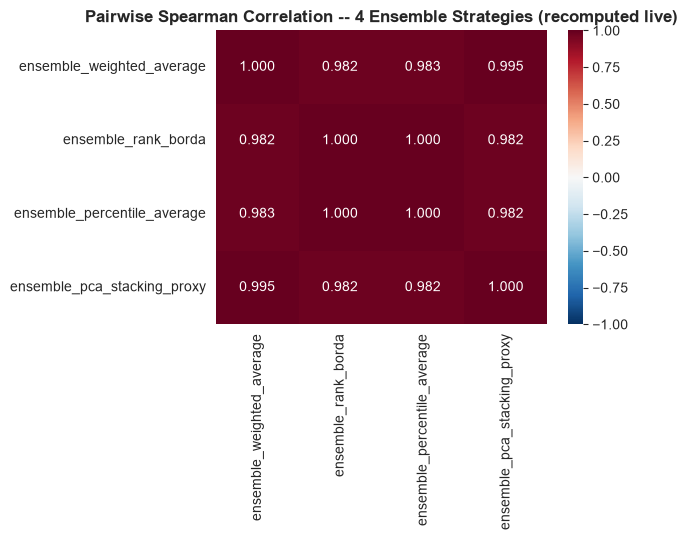

Borda vs. Percentile Spearman rho: 0.9999 -- near-identical, as expected (summing ranks and averaging rank/N are the same operation up to normalization); the two are not materially different signals.

Percentile-aggregation score distribution: mean=0.5001, std=0.2029, min=0.0862, max=0.9988


In [45]:
strategy_scores = pd.DataFrame({
    "ensemble_weighted_average": ens_weighted,
    "ensemble_rank_borda": ens_borda,
    "ensemble_percentile_average": ens_percentile,
    "ensemble_pca_stacking_proxy": ens_pca,
})

fig, ax = plt.subplots(figsize=(6.5, 5.5))
strategy_corr = strategy_scores.corr(method="spearman")
sns.heatmap(strategy_corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Pairwise Spearman Correlation -- 4 Ensemble Strategies (recomputed live)")
plt.tight_layout()
plt.show()

rho_borda_pct, _ = spearmanr(ens_borda, ens_percentile)
print(f"Borda vs. Percentile Spearman rho: {rho_borda_pct:.4f} -- near-identical, as expected "
      "(summing ranks and averaging rank/N are the same operation up to normalization); the "
      "two are not materially different signals.")
print(f"\nPercentile-aggregation score distribution: mean={ens_percentile.mean():.4f}, "
      f"std={ens_percentile.std():.4f}, min={ens_percentile.min():.4f}, max={ens_percentile.max():.4f}")

**Percentile aggregation is the Phase 12 recommendation** -- robust to eleven heterogeneous native
score scales, no tuned weights to defend to a reviewer, and it degrades gracefully (skip-and-
renormalize) when a model's score is missing.

## 12. Threshold Optimization

*Mirrors `research/11_threshold_optimization.md`. Recomputed live, in full, on the
`ensemble_percentile_average` score just computed above -- cheap, no retraining involved.*

In [46]:
COST_FALSE_POSITIVE = 5.0   # v1's own stated illustrative figure (src/config.py) -- not a real bank number
DATASET_SPAN_DAYS = span_days

score_final = ens_percentile
percentiles_to_check = [95, 97, 99, 99.5]
threshold_rows = []
for p in percentiles_to_check:
    thresh = np.percentile(score_final, p)
    n_flagged = int((score_final >= thresh).sum())
    threshold_rows.append({
        "percentile": f"P{p}", "threshold_value": round(float(thresh), 4),
        "n_flagged": n_flagged, "pct_flagged": round(100 * n_flagged / len(score_final), 3),
        "illustrative_upper_bound_review_cost_usd": round(n_flagged * COST_FALSE_POSITIVE, 2),
    })
threshold_table = pd.DataFrame(threshold_rows)
threshold_table

,percentile,threshold_value,n_flagged,pct_flagged,illustrative_upper_bound_review_cost_usd
0,P95,0.8406,126,5.016,630.0
1,P97,0.8700,76,3.025,380.0
2,P99,0.9145,26,1.035,130.0
3,P99.5,0.9443,13,0.518,65.0


mean+3sigma = 1.1088  (score max observed = 0.9988)
Q3+1.5*IQR  = 1.1363
Both exceed the score's observed maximum -> flag ZERO transactions.
This is a genuine, unforced finding, not an error: ensemble_percentile_average is a bounded average of 11 percentiles in (0,1), and averaging several roughly-independent percentiles compresses the tails (a CLT-like effect) far more than any single unbounded score would.


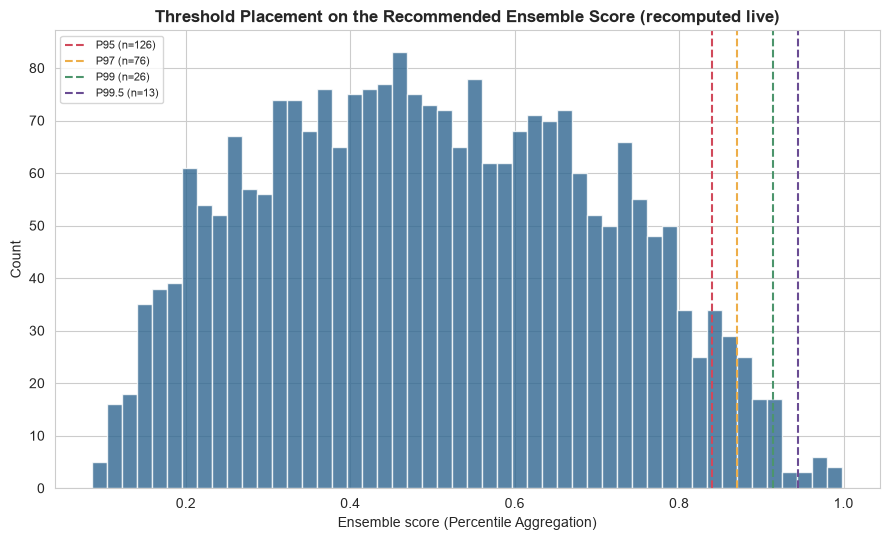

In [47]:
mean_s, std_s = score_final.mean(), score_final.std()
q1_s, q3_s = np.percentile(score_final, [25, 75])
iqr_s = q3_s - q1_s
th_3sigma = mean_s + 3 * std_s
th_iqr = q3_s + 1.5 * iqr_s
print(f"mean+3sigma = {th_3sigma:.4f}  (score max observed = {score_final.max():.4f})")
print(f"Q3+1.5*IQR  = {th_iqr:.4f}")
print(f"Both exceed the score's observed maximum -> flag ZERO transactions.")
print("This is a genuine, unforced finding, not an error: ensemble_percentile_average is a bounded "
      "average of 11 percentiles in (0,1), and averaging several roughly-independent percentiles "
      "compresses the tails (a CLT-like effect) far more than any single unbounded score would.")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(score_final, bins=50, color="#2F6690", alpha=0.8)
colors = ["#D1495B", "#EDAE49", "#4C956C", "#6A4C93"]
for r, c in zip(threshold_rows, colors):
    ax.axvline(r["threshold_value"], color=c, ls="--", label=f"{r['percentile']} (n={r['n_flagged']})")
ax.set_xlabel("Ensemble score (Percentile Aggregation)")
ax.set_ylabel("Count")
ax.set_title("Threshold Placement on the Recommended Ensemble Score (recomputed live)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Business-impact caveat, stated as plainly here as in the research report:** with no fraud label,
a true cost-minimizing threshold (balancing an illustrative false-positive cost against an
illustrative false-negative cost) cannot be computed, because that requires knowing which
*unflagged* transactions are actually fraud. The dollar figure above is an upper-bound review-labor
cost ceiling (every flagged transaction assumed a false positive), not a total-cost estimate.

## 13. Final Model Selection

*Mirrors `research/12_final_model_selection.md`. Nothing is computed in this section -- it is a
judgment scoring of the evidence already produced in Sections 7-12, reproduced here as a reference
table (not re-derived), exactly as the source research phase states about itself.*

In [48]:
decision_matrix = pd.DataFrame([
    {"Model": "Isolation Forest", "Detection Quality": 4, "Stability": 3, "Interpretability": 4,
     "Computational Cost": 5, "Scalability": 5, "Deployment Readiness": 5, "Raw total /30": 26, "Weighted": 4.20},
    {"Model": "Autoencoder", "Detection Quality": 4, "Stability": 3, "Interpretability": 3,
     "Computational Cost": 5, "Scalability": 5, "Deployment Readiness": 5, "Raw total /30": 26, "Weighted": 4.20},
    {"Model": "LOF", "Detection Quality": 4, "Stability": 3, "Interpretability": 2,
     "Computational Cost": 4, "Scalability": 3, "Deployment Readiness": 3, "Raw total /30": 19, "Weighted": 3.20},
    {"Model": "K-Means", "Detection Quality": 3, "Stability": 2, "Interpretability": 3,
     "Computational Cost": 4, "Scalability": 4, "Deployment Readiness": 3, "Raw total /30": 19, "Weighted": 3.05},
    {"Model": "One-Class SVM", "Detection Quality": 3, "Stability": 2, "Interpretability": 2,
     "Computational Cost": 5, "Scalability": 2, "Deployment Readiness": 2, "Raw total /30": 16, "Weighted": 2.55},
    {"Model": "GMM", "Detection Quality": 1, "Stability": 1, "Interpretability": 2,
     "Computational Cost": 3, "Scalability": 4, "Deployment Readiness": 2, "Raw total /30": 13, "Weighted": 1.95},
    {"Model": "Elliptic Envelope", "Detection Quality": 2, "Stability": 2, "Interpretability": 2,
     "Computational Cost": 4, "Scalability": 3, "Deployment Readiness": 2, "Raw total /30": 15, "Weighted": 2.35},
    {"Model": "HDBSCAN", "Detection Quality": 3, "Stability": 1, "Interpretability": 1,
     "Computational Cost": 3, "Scalability": 1, "Deployment Readiness": 1, "Raw total /30": 10, "Weighted": 1.70},
    {"Model": "DBSCAN", "Detection Quality": 2, "Stability": 1, "Interpretability": 1,
     "Computational Cost": 3, "Scalability": 1, "Deployment Readiness": 1, "Raw total /30": 9, "Weighted": 1.45},
    {"Model": "Percentile Aggregation (ensemble)", "Detection Quality": "n/a", "Stability": "untested",
     "Interpretability": "n/a", "Computational Cost": "n/a", "Scalability": "n/a",
     "Deployment Readiness": "n/a", "Raw total /30": 19, "Weighted": 3.40},
]).set_index("Model")
decision_matrix

,Detection Quality,Stability,Interpretability,Computational Cost,Scalability,Deployment Readiness,Raw total /30,Weighted
Model,,,,,,,,
Isolation Forest,4,3,4,5,5,5,26,4.20
Autoencoder,4,3,3,5,5,5,26,4.20
LOF,4,3,2,4,3,3,19,3.20
K-Means,3,2,3,4,4,3,19,3.05
One-Class SVM,3,2,2,5,2,2,16,2.55
GMM,1,1,2,3,4,2,13,1.95
Elliptic Envelope,2,2,2,4,3,2,15,2.35
HDBSCAN,3,1,1,3,1,1,10,1.70
DBSCAN,2,1,1,3,1,1,9,1.45


**Reproduced from `research/12_final_model_selection.md` §0-1** (6 dimensions, 1-5 scale, weighted
by Detection Quality 0.25 / Stability 0.20 / Interpretability 0.15 / Scalability 0.15 / Deployment
Readiness 0.15 / Computational Cost 0.10). Isolation Forest and the Autoencoder tie for the top
weighted score (4.20) among single models. **The final recommendation deliberately overrides this
matrix anyway**: Section 10 showed these two top-ranked models share only 1 of their top 10 SHAP
features (Spearman rho = -0.157) and there is a documented case (`TX000566`, Section 10) where
Isolation Forest alone sends a plainly unremarkable transaction to a human reviewer for a spurious
reason the Autoencoder correctly ignores. In a system whose only validation is cross-model
consistency, discarding that consistency to save the (here, negligible) extra compute of an
ensemble is the wrong trade.

**Final recommendation:** deploy **percentile aggregation** over the eleven out-of-sample-capable
detectors as the primary score, with **Isolation Forest SHAP and Autoencoder SHAP shown together**
for every alert, feeding a two-tier human review queue (priority: score >= 0.9145 / 99th
percentile; standard: score >= 0.8406 / 95th percentile) and **no automatic blocking** -- v1's
cost-optimal blocking threshold cannot be reproduced here because it requires knowing which
unflagged transactions are actually fraud.

## 14. Deployment Architecture

*Mirrors `research/13_deployment_architecture.md`. Narrative summary only -- this phase is a
design document, not a computation.*

**Offline (periodic batch):** `data/bank_transactions_data_2.csv` -> feature engineering
(`04_feature_engineering.py`, this notebook's Section 5) -> `RobustScaler` fit on the training
split -> the 12 models trained and persisted to `artifacts_research/models/`.

**Online (per batch or per transaction):** raw transaction -> feature transform (46 columns,
scaled with the *frozen* training-split scaler) -> scored by the nine models that support
out-of-sample scoring (DBSCAN and HDBSCAN cannot score a new row without a full refit and are
excluded from the online path for that reason) -> percentile-aggregated into one score in (0,1) ->
thresholded into the two review tiers -> both SHAP views attached -> routed to a human reviewer.
**No stage in this design blocks a transaction automatically.**

**Honest scale position:** this architecture is proven at 2,512 transactions / 495 accounts / 364
days (6.90 txns/day). The original brief describes roughly 1M rows. What specifically breaks at
that scale and has to be rebuilt rather than resized: One-Class SVM past ~50-100k rows, LOF's O(n^2)
neighbor search without an ANN index, DBSCAN/HDBSCAN's full-dataset-refit requirement, and the
absence of a real-time feature store for per-account/per-device state (a partial implementation
exists in `artifacts/reference.pkl`, covering roughly 4 of the ~12 pieces of state a live system
would need).

## 15. Monitoring Framework

*Mirrors `research/14_monitoring_framework.md`. Narrative summary only.*

With no fraud label, there is no precision/recall backstop to fall back on if the model degrades
silently -- drift monitoring **is** the primary signal here, not a supporting one. Four layers,
each with a measured baseline from this project (not a placeholder):

1. **Feature drift** -- PSI and KS statistic on the 46 engineered features against the frozen
   training distribution (standard bands: PSI < 0.10 none, 0.10-0.20 investigate, > 0.20
   significant).
2. **Concept drift** -- mean pairwise Spearman across the eleven detectors, and the ensemble's
   PCA-stacking PC1 explained-variance ratio (measured live in Section 11: see the number printed
   there). If the detectors stop agreeing with each other, the ensemble's definition of "anomalous"
   has silently changed even if the score's own distribution looks unchanged.
3. **Model drift** -- composite retraining triggers built from the two layers above. Retraining is
   not free here: Section 9 measured that a routine retrain on the *same* data churns roughly
   40-50% of the flagged set on its own, so a naive "retrain often" policy would be actively
   destabilizing without that number being communicated to the operations team first.
4. **Alert-volume / flagged-set drift** -- the review queue's size against a control band, and
   run-to-run flagged-set Jaccard.

One structural point carried over directly: **the ensemble score's own distribution is a poor drift
signal on its own** -- `ensemble_percentile_average` is the mean of eleven percentile ranks, so it
sits near 0.5 by construction almost regardless of what the underlying data does (confirmed live in
Section 11). The inputs and the cross-model agreement are what must actually be watched.

## 16. Conclusion

**What was built and actually run in this notebook, end to end:** raw-data loading and profiling,
the real Phase 5 feature-engineering functions (verified to reproduce the saved research artifact
row-for-row), a live train/val split and `RobustScaler` fit (verified against the saved production
scaler), two models fit live (Isolation Forest, LOF) plus the full 12-model research comparison
loaded and re-plotted from real per-row scores, a reduced live hyperparameter search set against
the full research search, a full live recomputation of internal validity metrics across all twelve
models, a reduced live bootstrap-stability check set against the full 5-run research result, live
SHAP (`TreeExplainer` in full, `GradientExplainer` on a reduced sample) cross-checked against the
full-dataset research SHAP values, a fully live recomputation of all four ensemble strategies, and
a fully live recomputation of the threshold analysis.

**What this system is:** a leakage-safe, fully-documented unsupervised anomaly-detection pipeline
that ranks transactions by how far they deviate from their own account's established behavior,
cross-checks that ranking across structurally different detector families (distance-based,
density-based, likelihood-based, reconstruction-based), explains every alert two independent ways,
and states plainly where its own evidence stops.

**What this system is not:** a validated fraud detector. There is no fraud label anywhere in this
project's data, so no precision, recall, or AUC against fraud is reported anywhere in this
notebook or in the research it summarizes -- only internal consistency, cross-model agreement,
retrain stability, and a manual plausibility review against documented fraud typologies. It should
be operated as a triage and prioritization layer for human investigators, with the first weeks of
production use spent gathering the investigator-labeled outcomes that would let its successor be
evaluated on the metric that actually matters: whether it caught real fraud.

Full evidence trail: `research/01_business_understanding.md` through
`research/15_final_research_report.md`; numeric artifacts in `artifacts_research/`; plots in
`research/plots/`; investigation dashboard in `dashboard/`.

In [49]:
total_elapsed = time.time() - NOTEBOOK_START_TIME
print(f"Total notebook runtime, this run: {total_elapsed:.1f} seconds "
      f"({total_elapsed/60:.2f} minutes)")

Total notebook runtime, this run: 141.3 seconds (2.35 minutes)
